Found Synapse note file: E:\resp_test_data\mouse5-250125-100112\Notes.txt
read from t=0s to t=302.25s


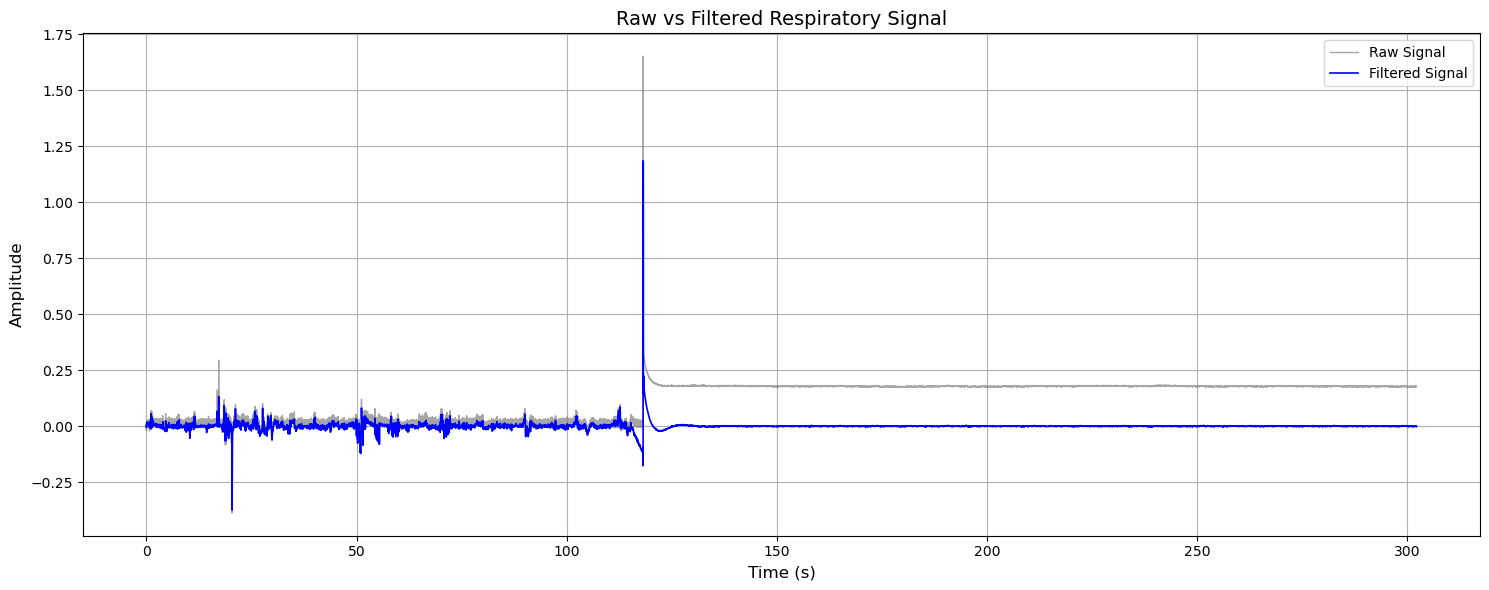

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import neurokit2 as nk
import tdt

# Load the TDT block
tdt_file_path = r"E:\resp_test_data\mouse5-250125-100112"
data = tdt.read_block(tdt_file_path)

# Extract respiratory signal
rsp_signal = data.streams['Resp'].data  # Adjust 'Resp' to match your stream name
srate = data.streams['Resp'].fs  # Sampling rate (Hz)
total_duration = len(rsp_signal) / srate  # Total duration in seconds
time_array = np.linspace(0, total_duration, len(rsp_signal))

# Smooth the respiratory signal
rsp_cleaned = nk.signal_filter(
    rsp_signal,
    lowcut=0.1,   # Low cutoff frequency (Hz)
    highcut=20,   # High cutoff frequency (Hz)
    method="butterworth",  # Filtering method
    sampling_rate=srate,   # Sampling rate of the signal
    order=4                # Filter order
)

# Plot raw and filtered signals
plt.figure(figsize=(15, 6))
plt.plot(time_array, rsp_signal, label="Raw Signal", color="gray", alpha=0.7, linewidth=1)
plt.plot(time_array, rsp_cleaned, label="Filtered Signal", color="blue", linewidth=1.2)
plt.xlabel("Time (s)", fontsize=12)
plt.ylabel("Amplitude", fontsize=12)
plt.title("Raw vs Filtered Respiratory Signal", fontsize=14)
plt.legend(loc="upper right")
plt.grid(True)
plt.tight_layout()
plt.show()


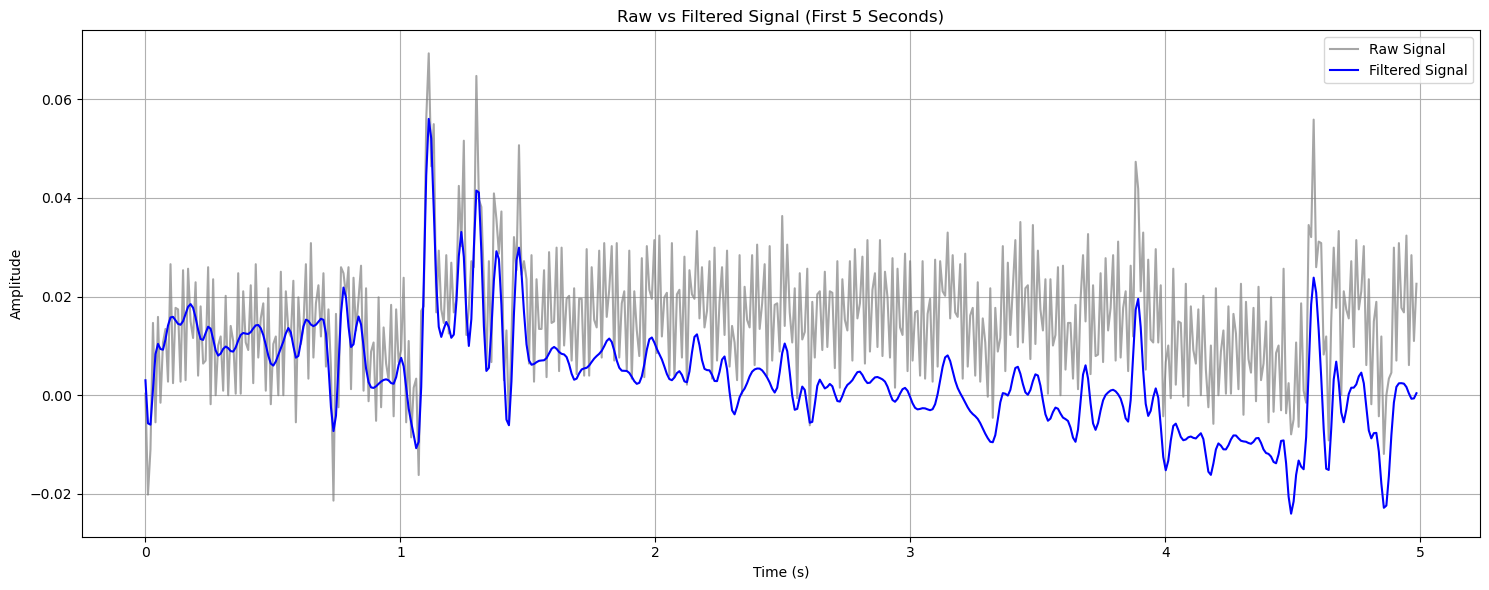

In [16]:
plt.figure(figsize=(15, 6))
plt.plot(time_array[:int(srate*5)], rsp_signal[:int(srate*5)], label="Raw Signal", color="gray", alpha=0.7)
plt.plot(time_array[:int(srate*5)], rsp_cleaned[:int(srate*5)], label="Filtered Signal", color="blue")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Raw vs Filtered Signal (First 5 Seconds)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Found Synapse note file: E:\resp_test_data\mouse5-250125-100112\Notes.txt
read from t=0s to t=302.25s


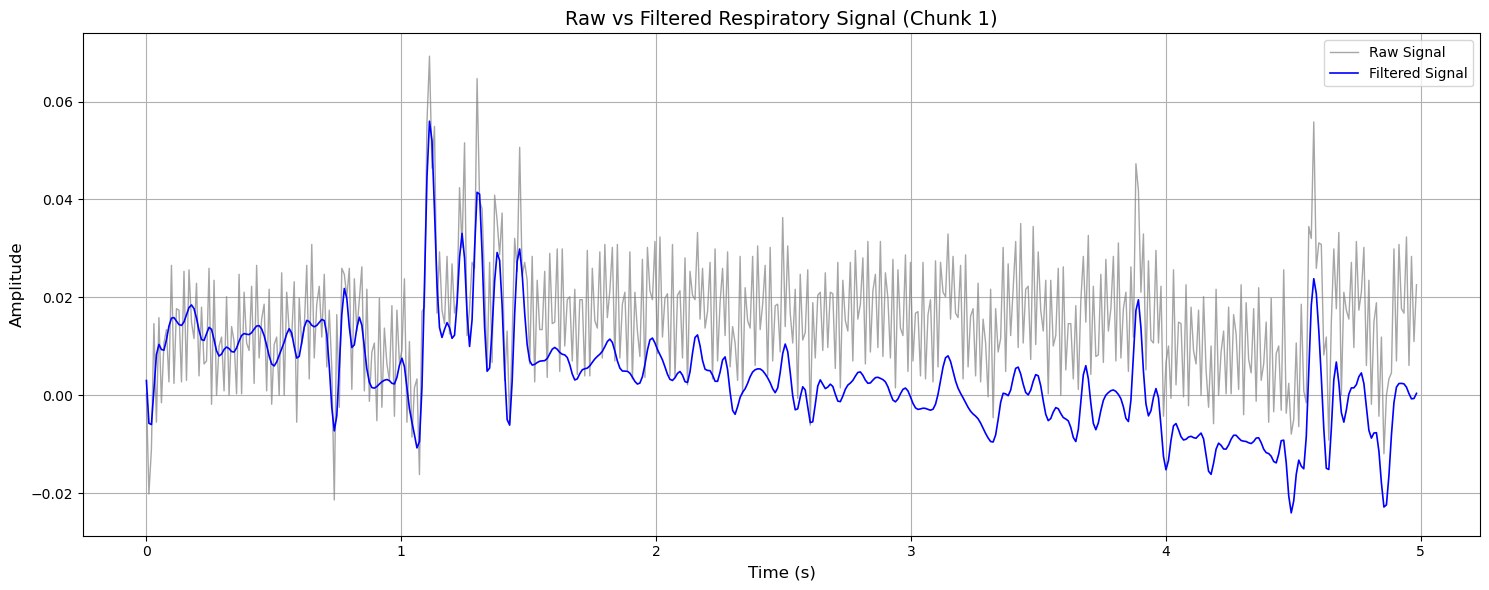

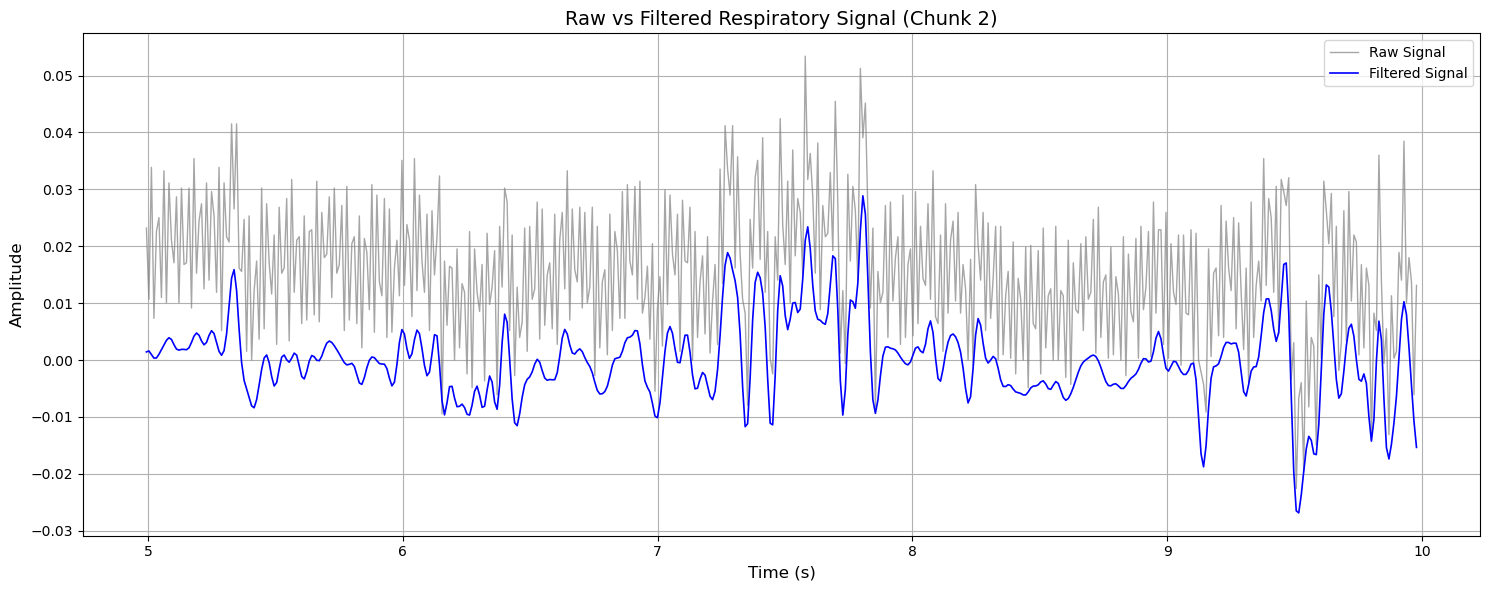

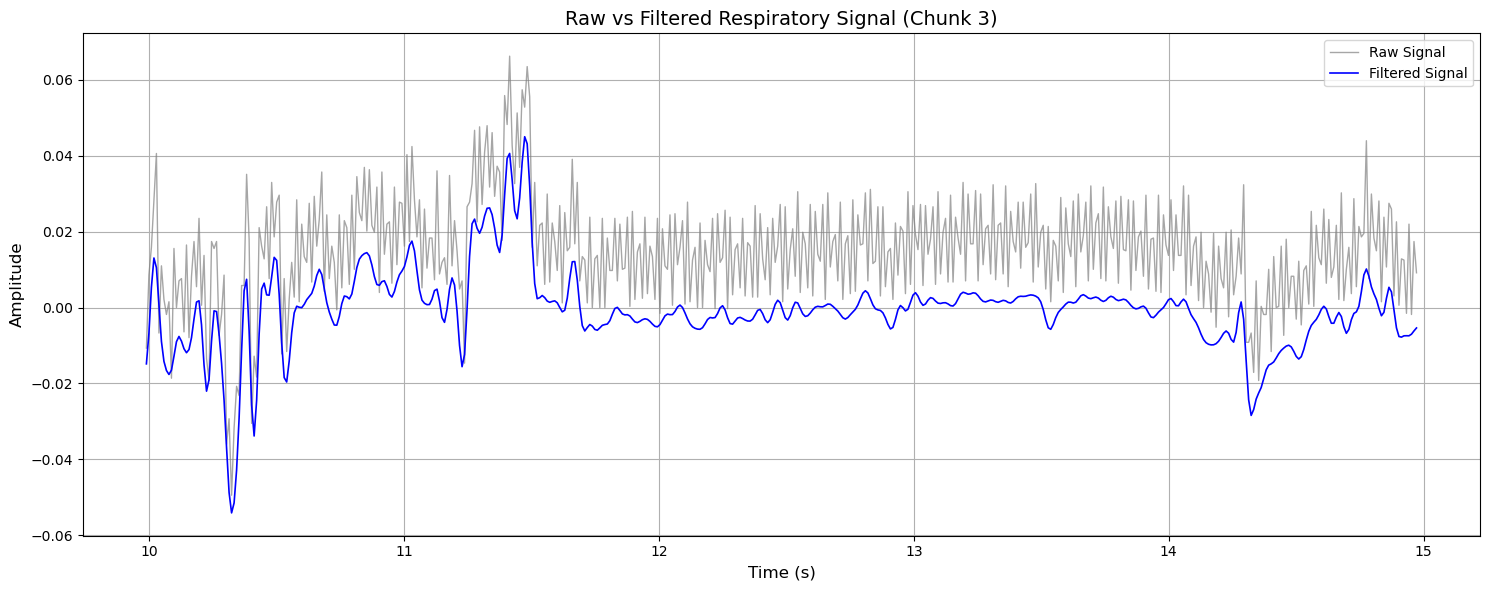

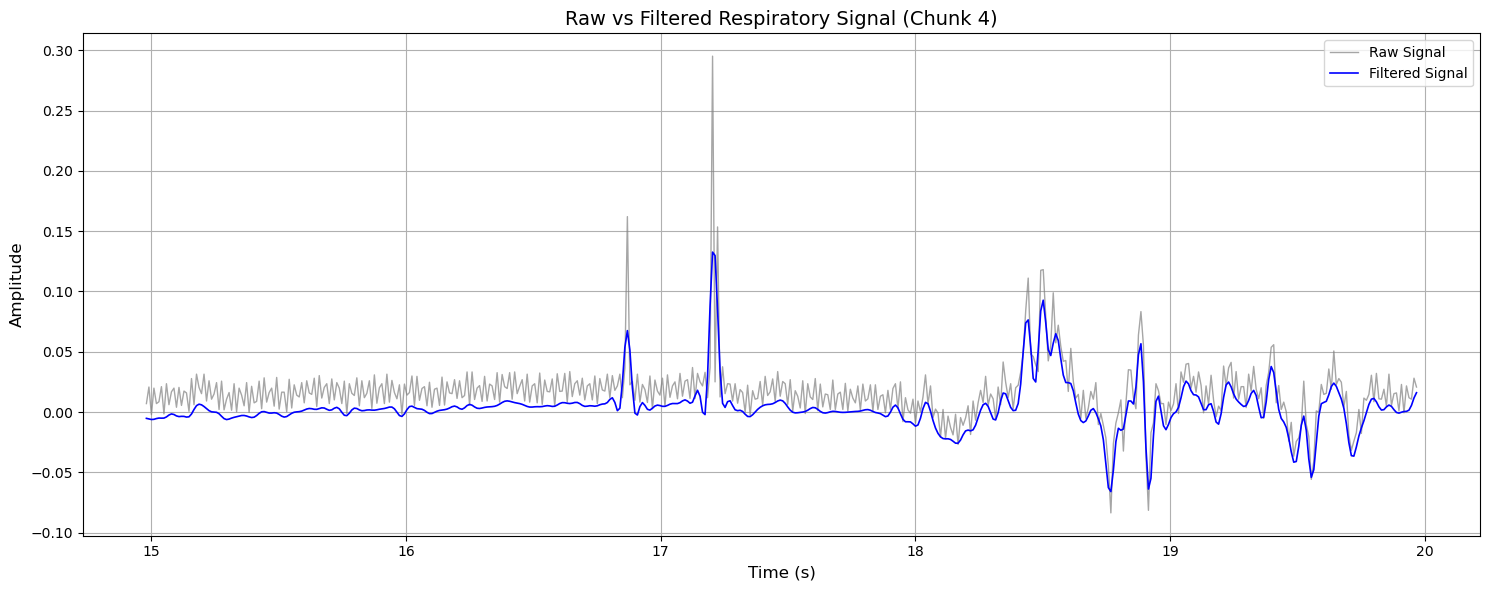

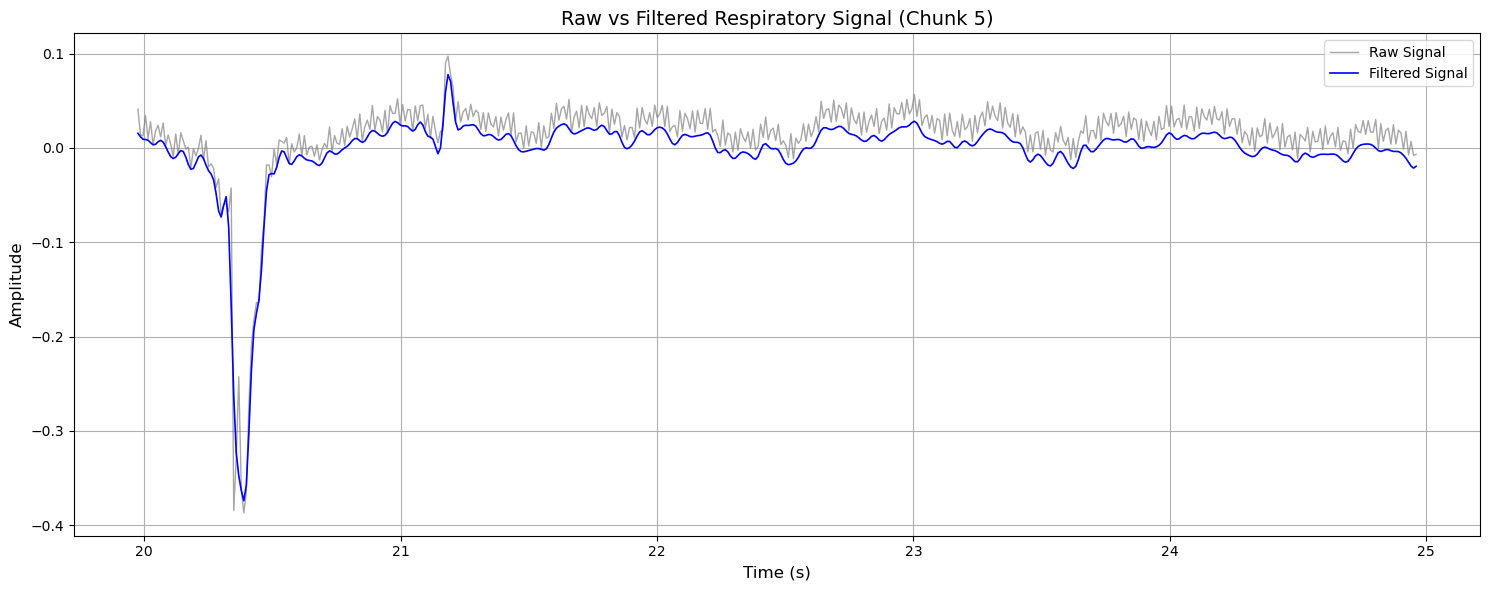

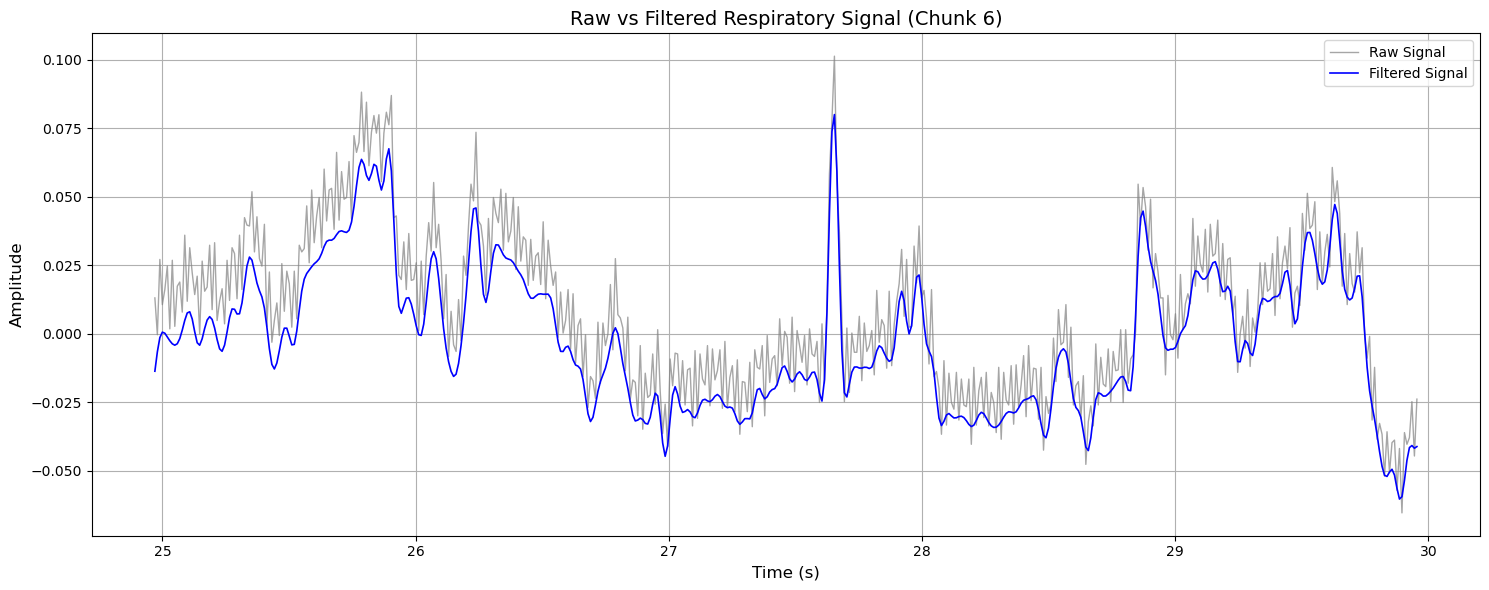

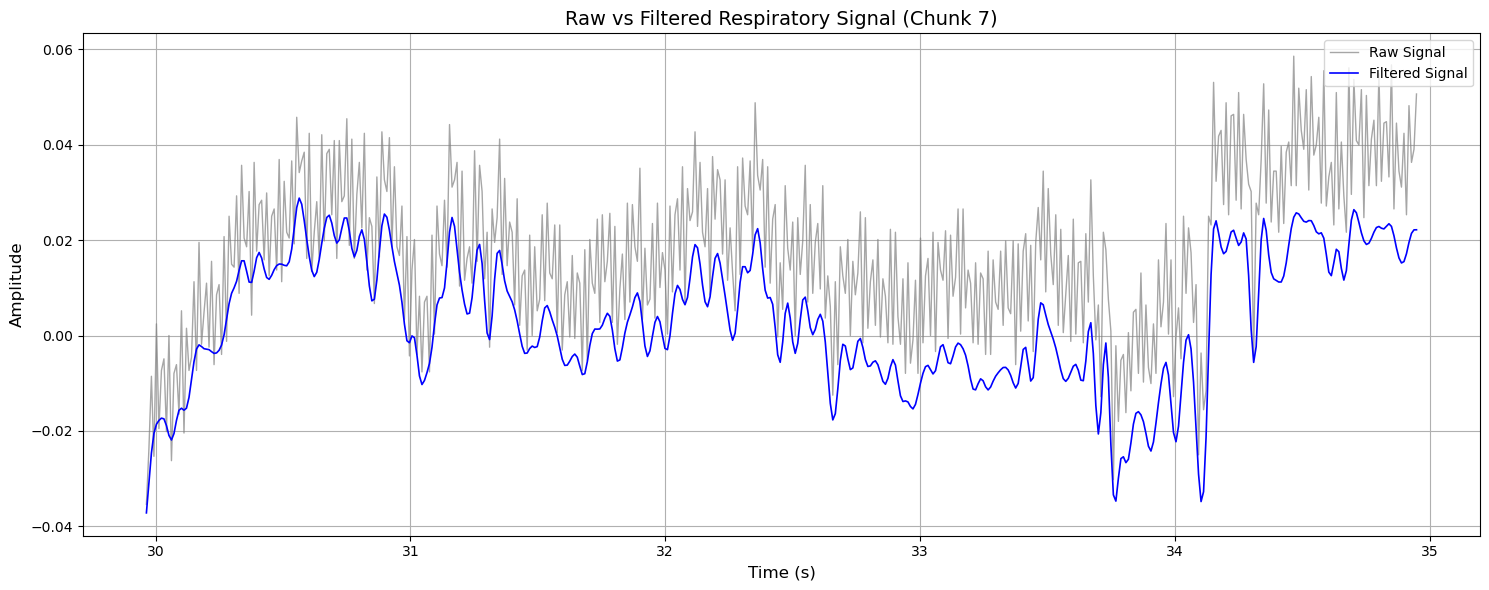

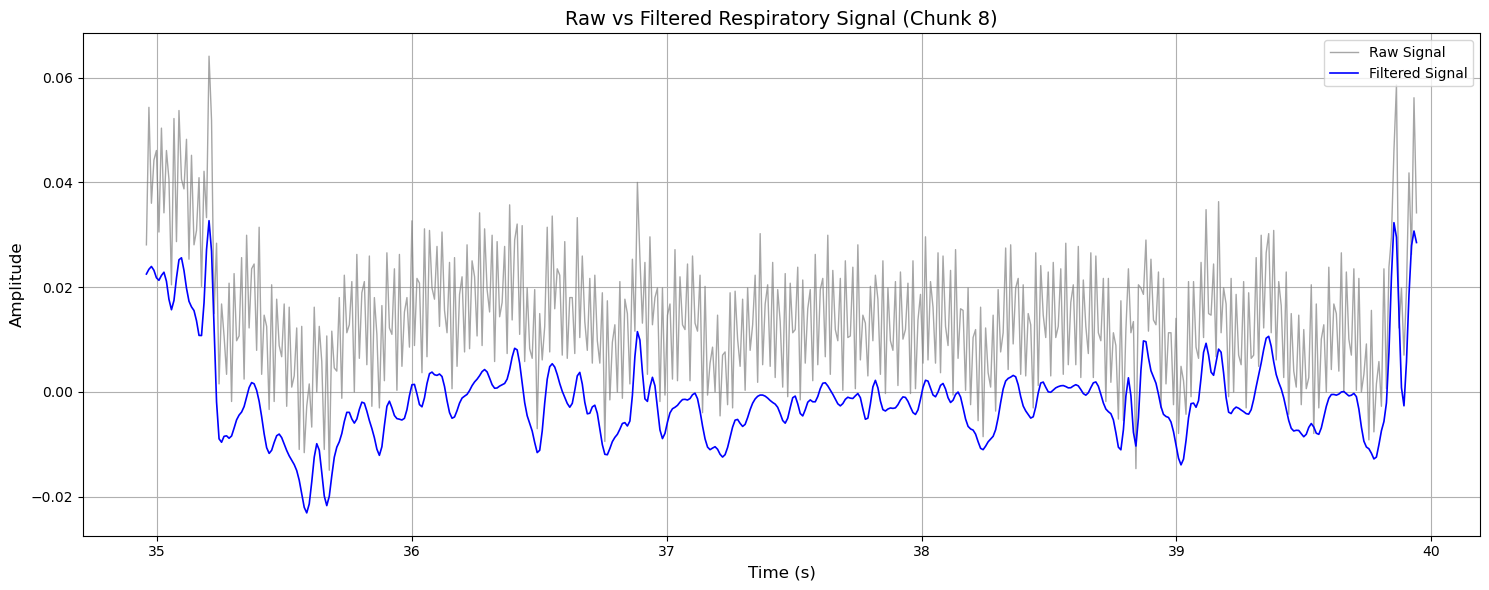

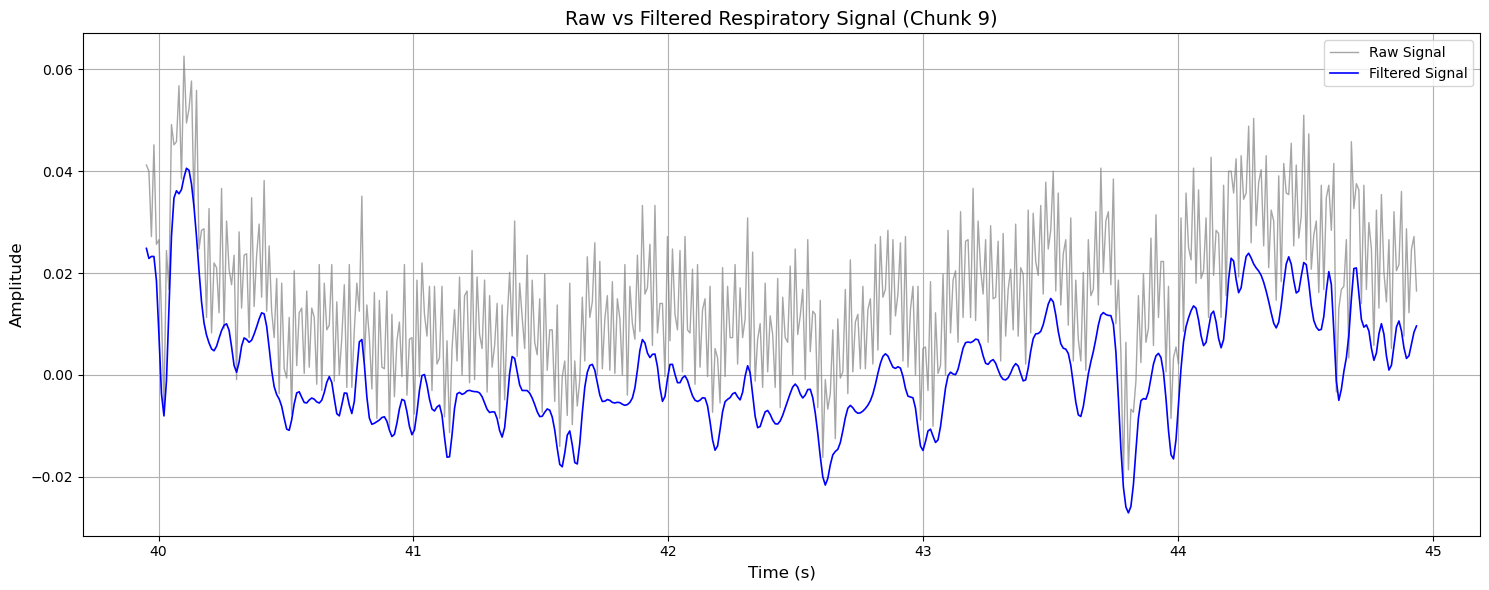

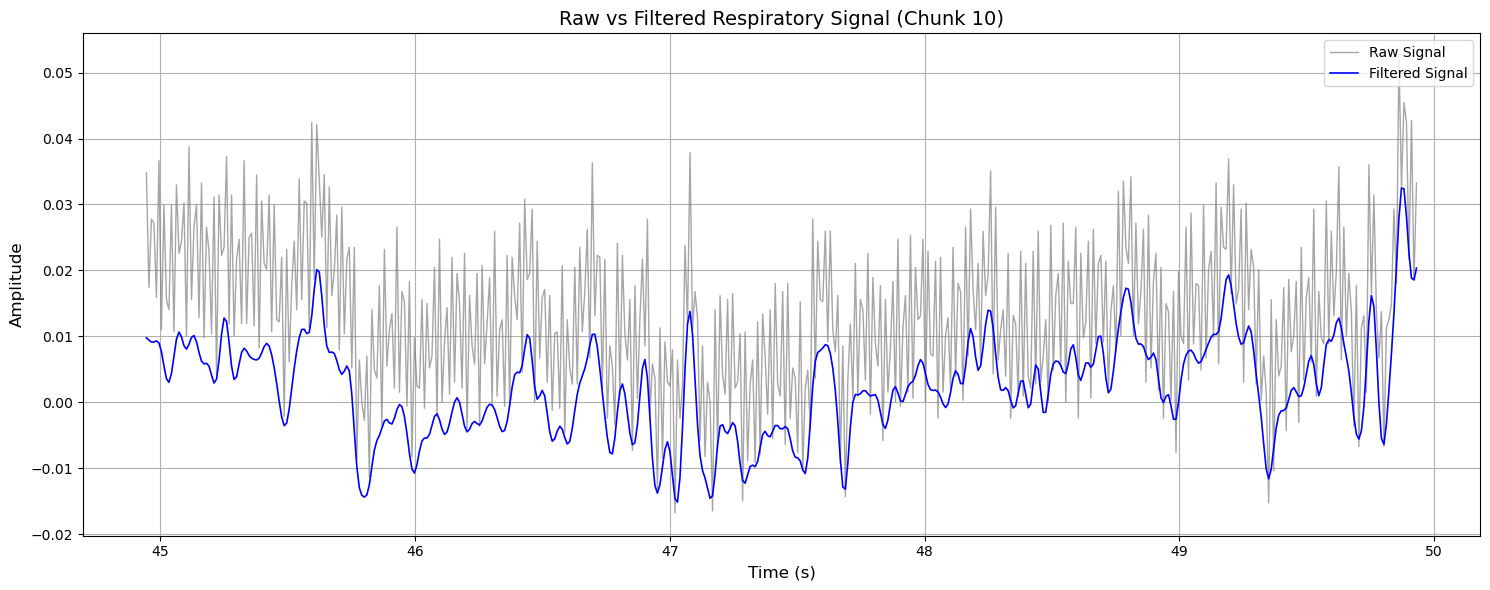

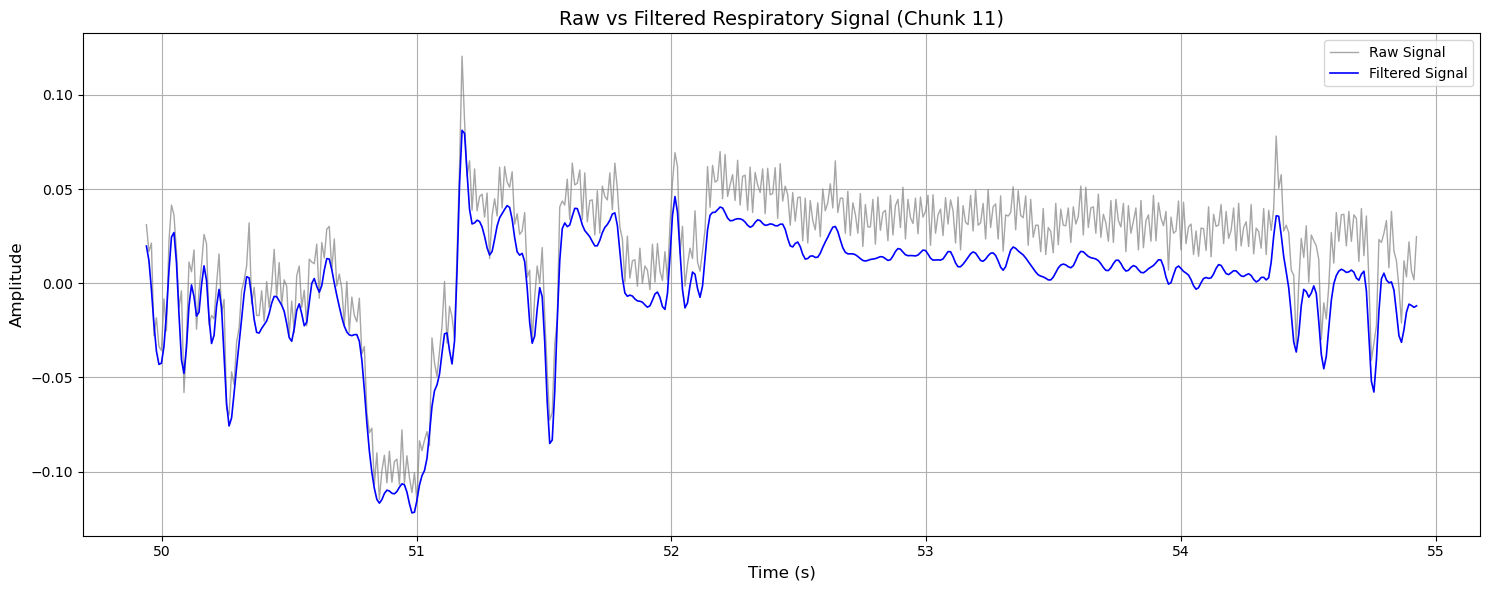

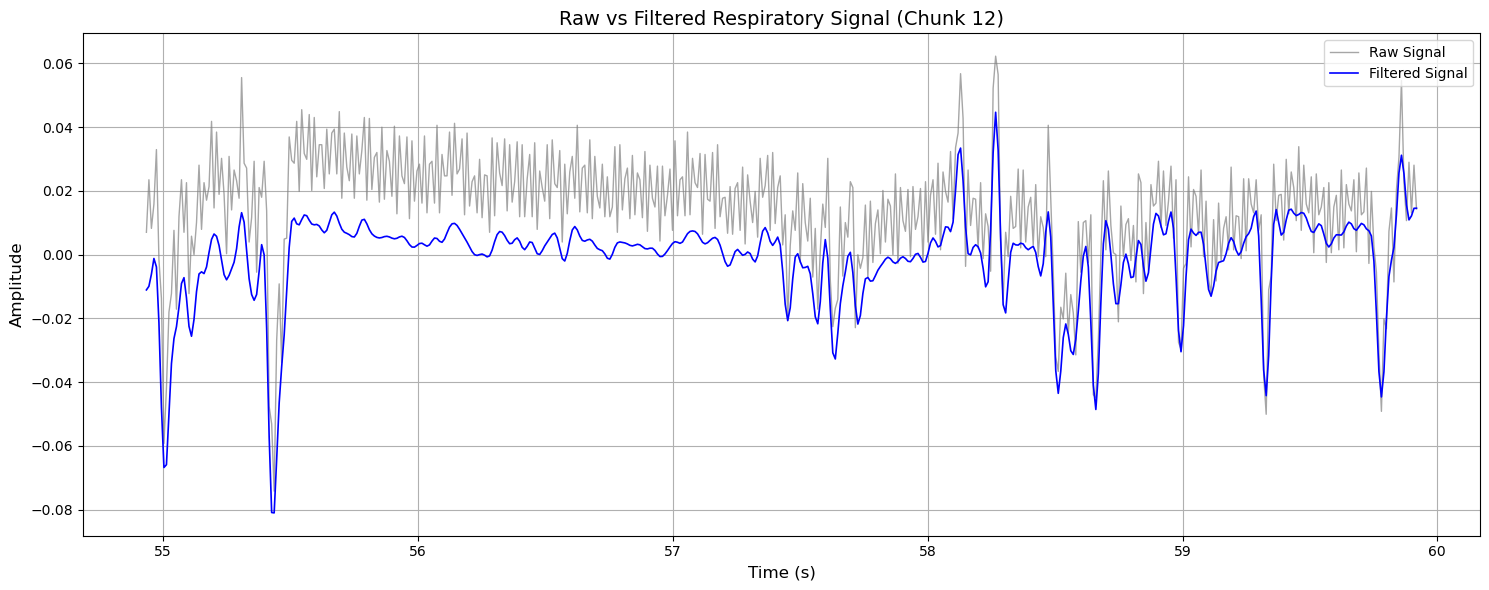

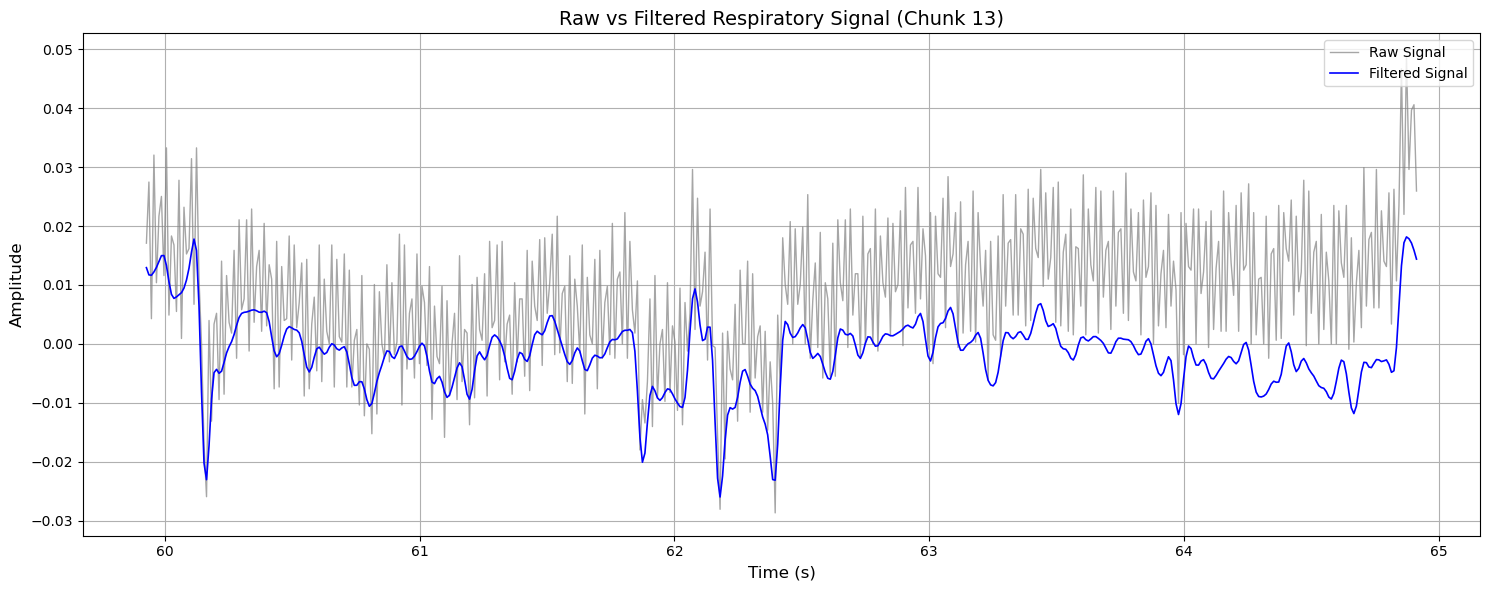

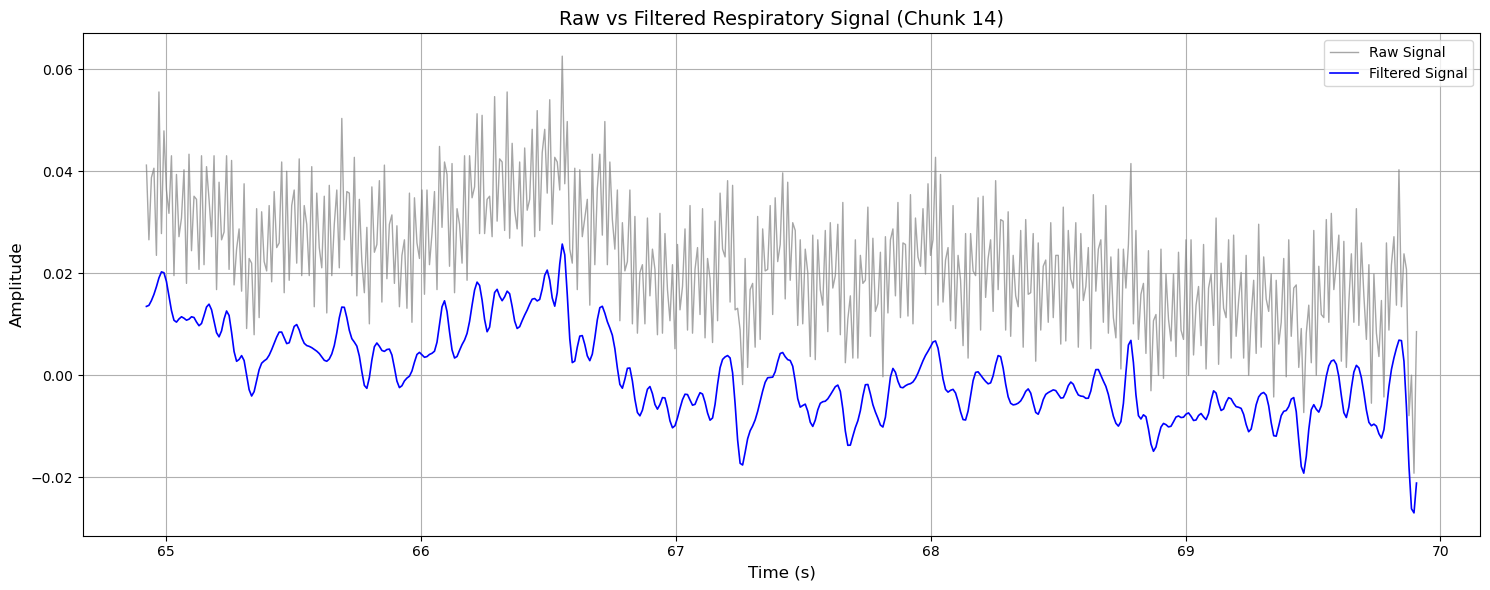

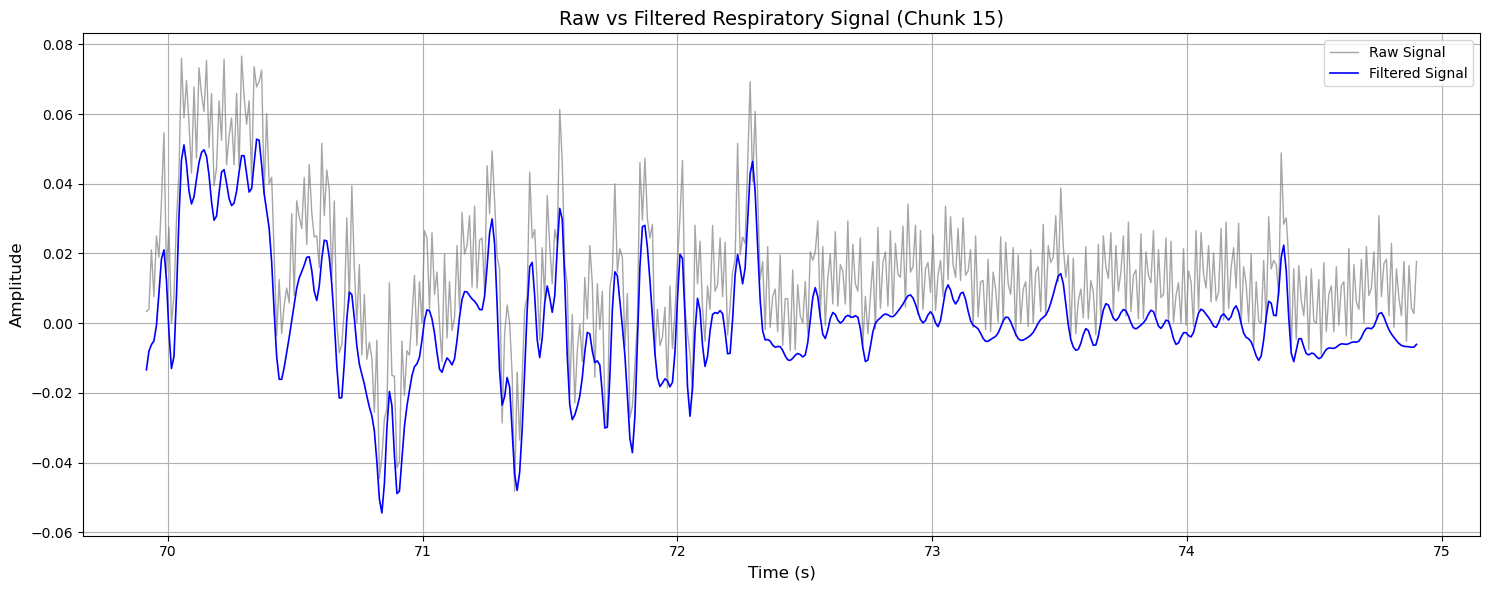

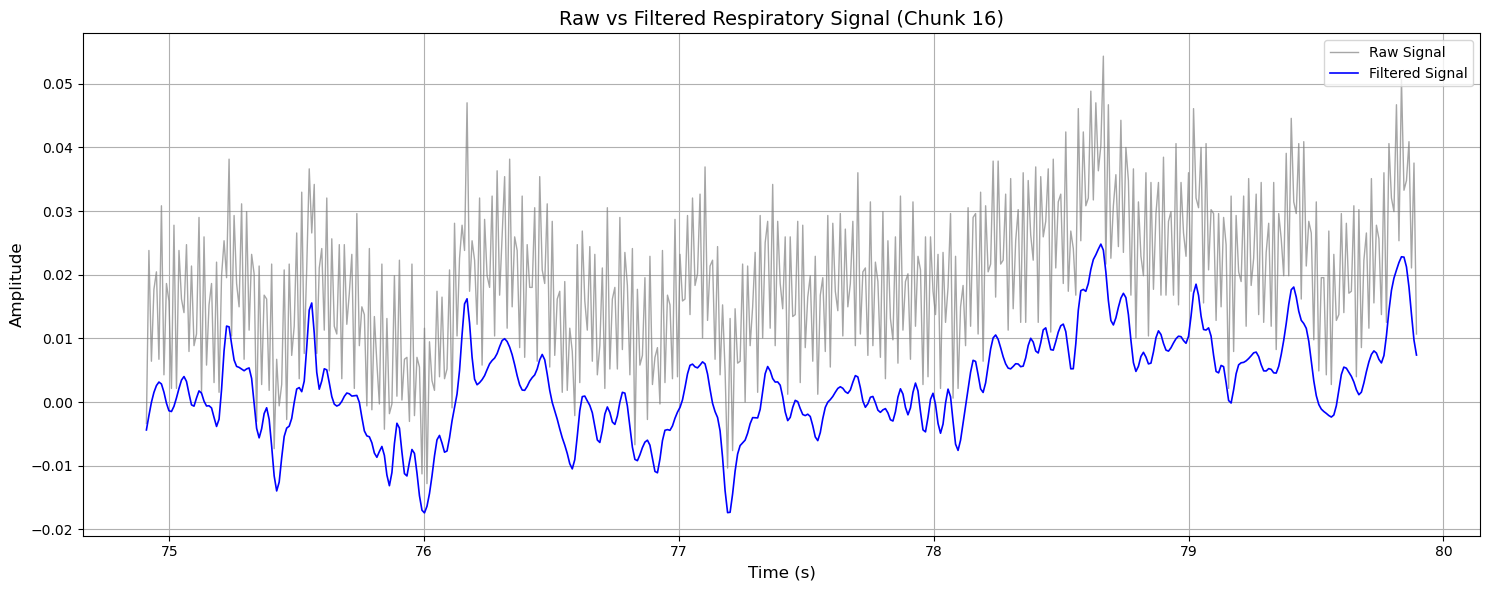

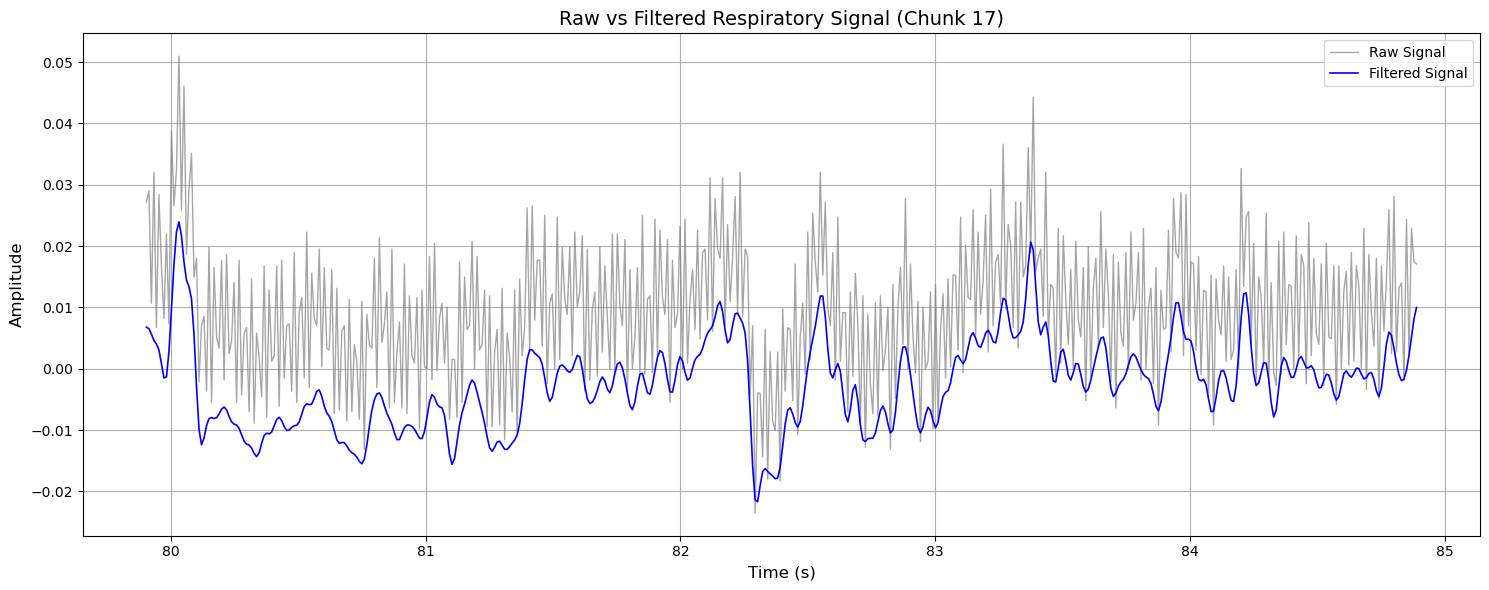

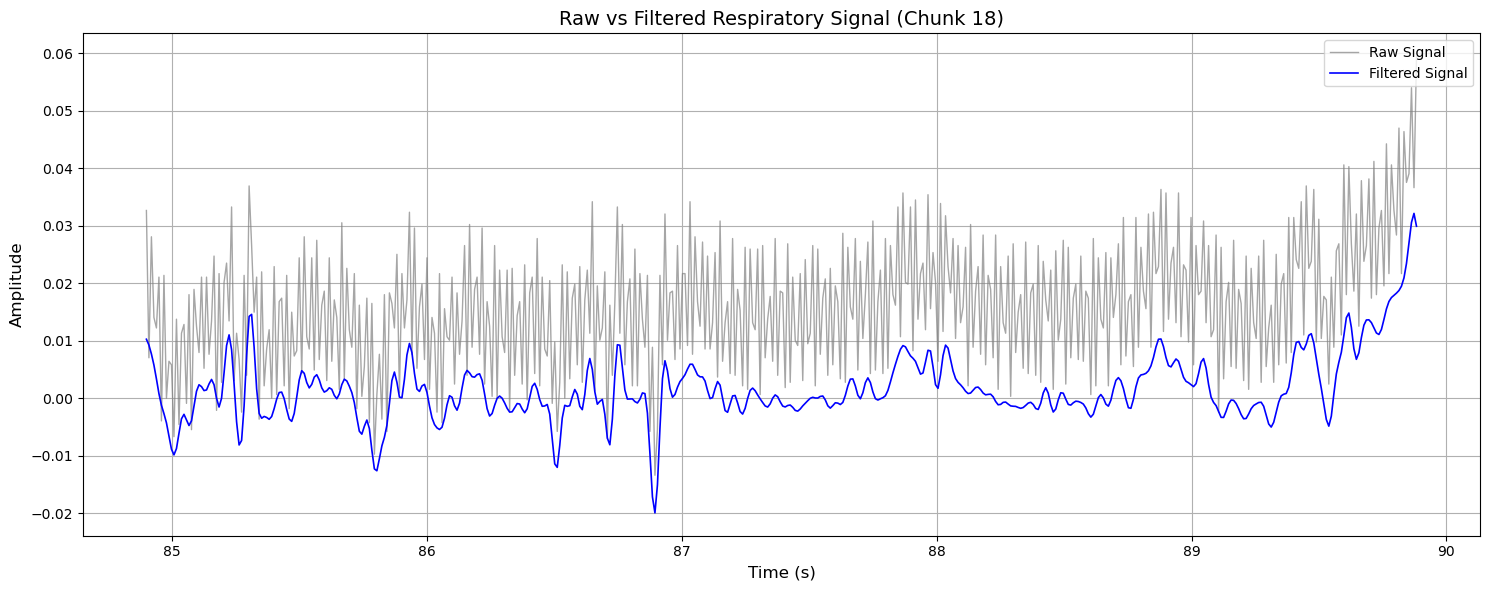

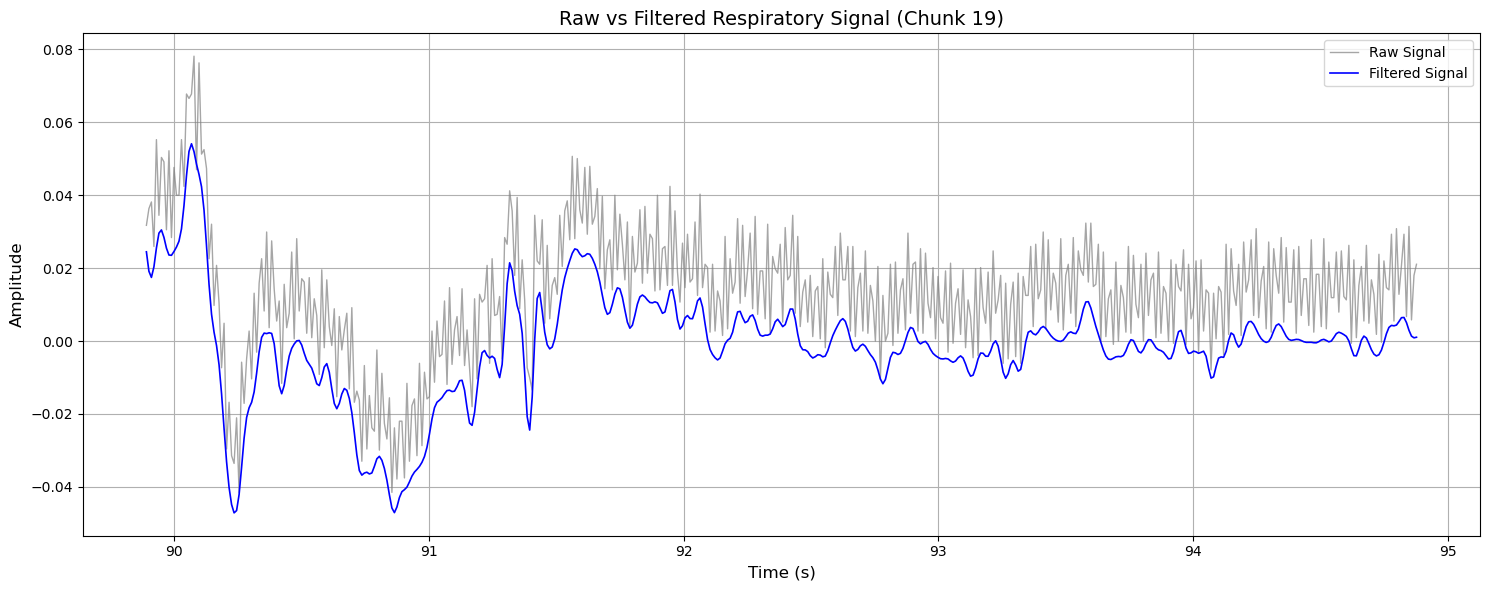

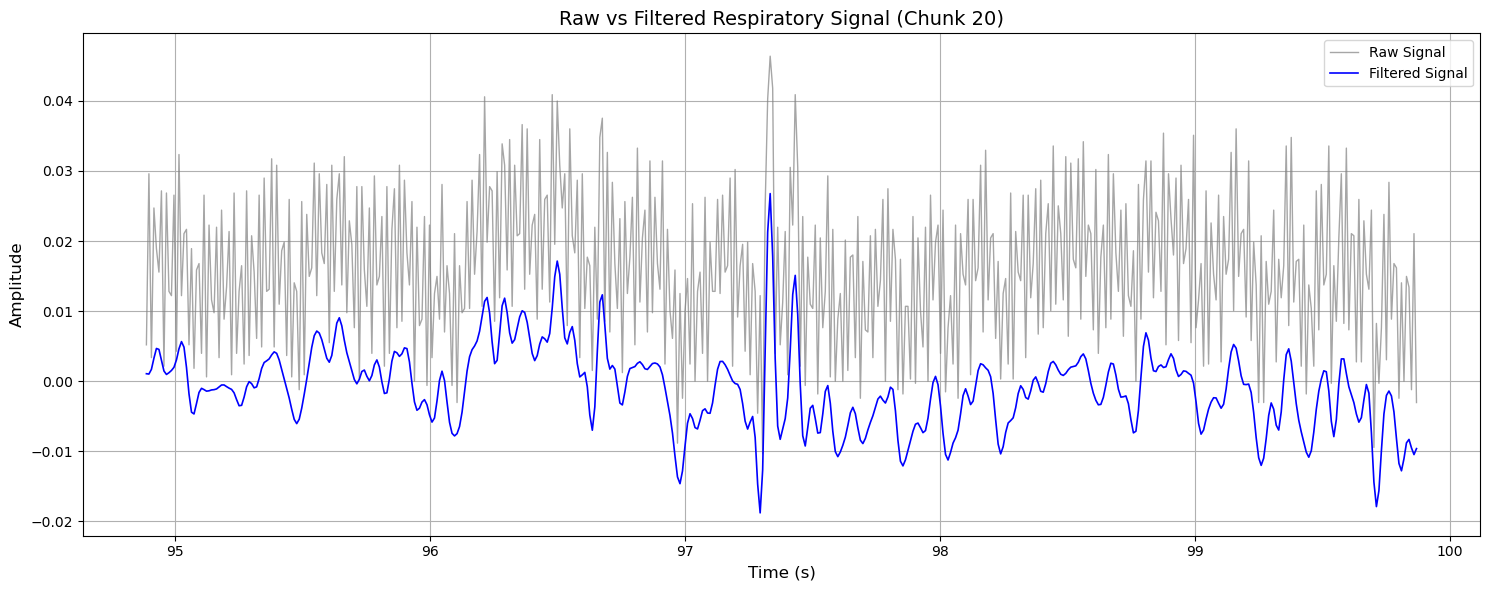

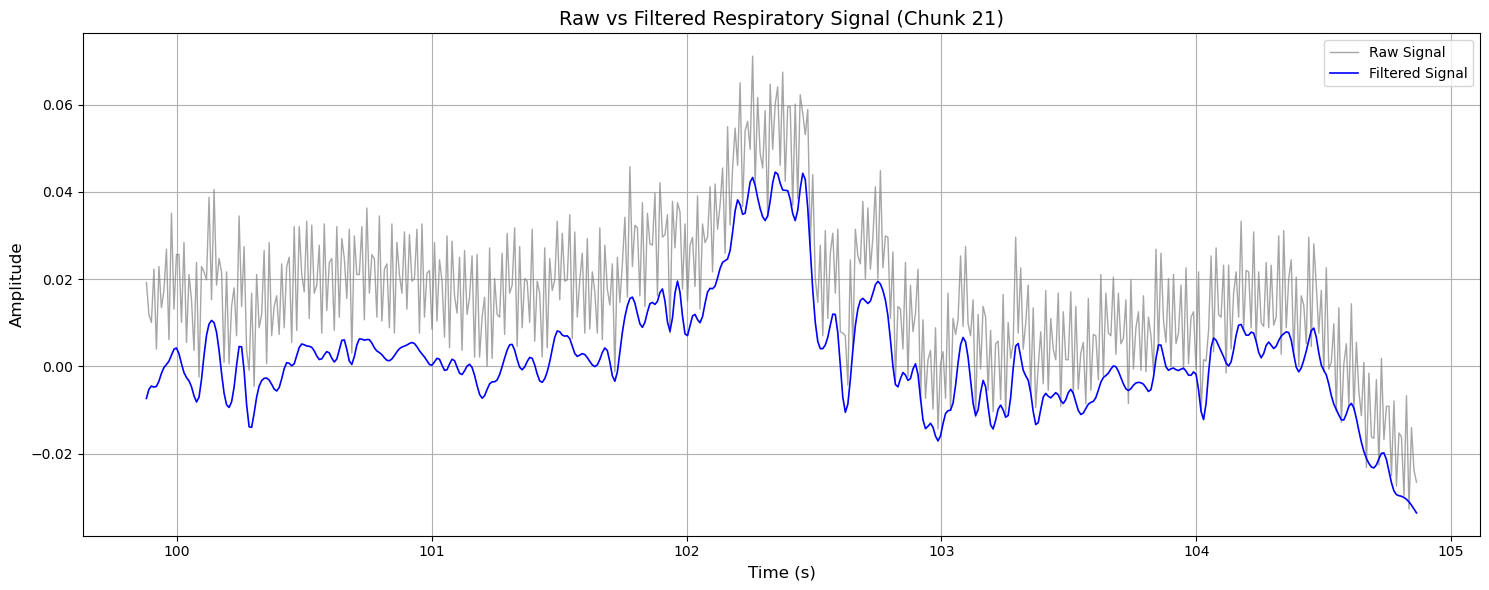

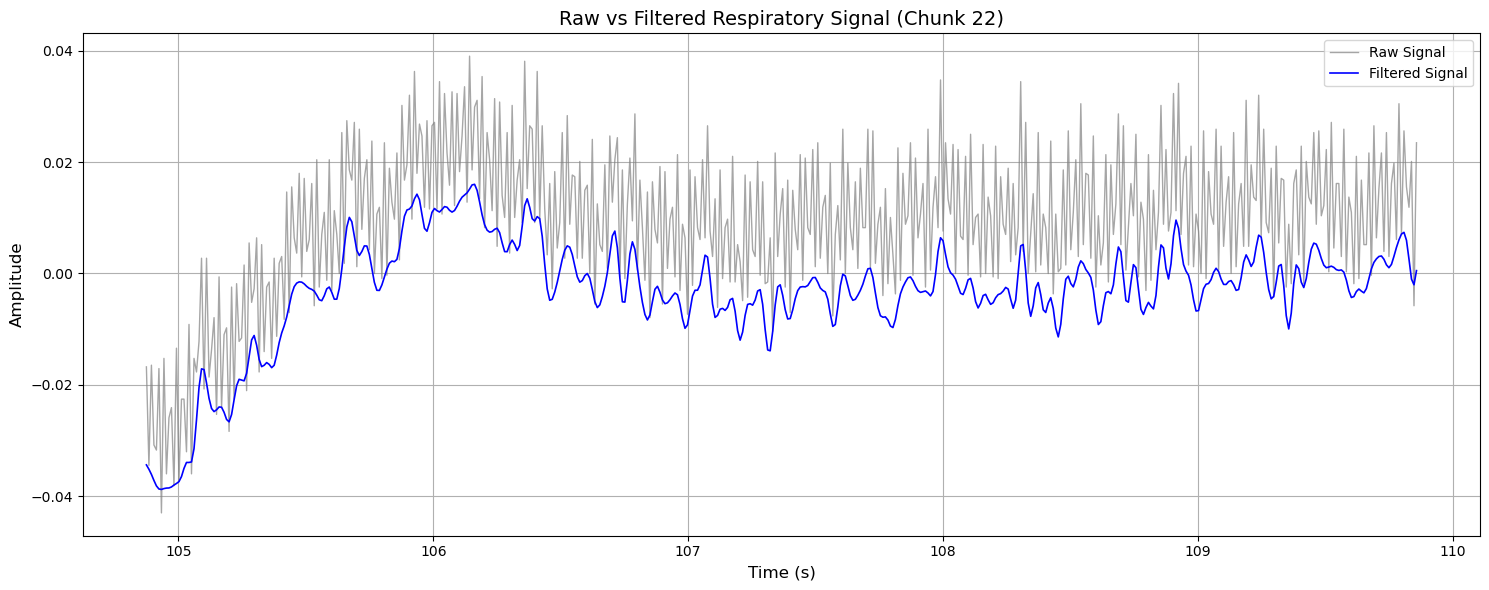

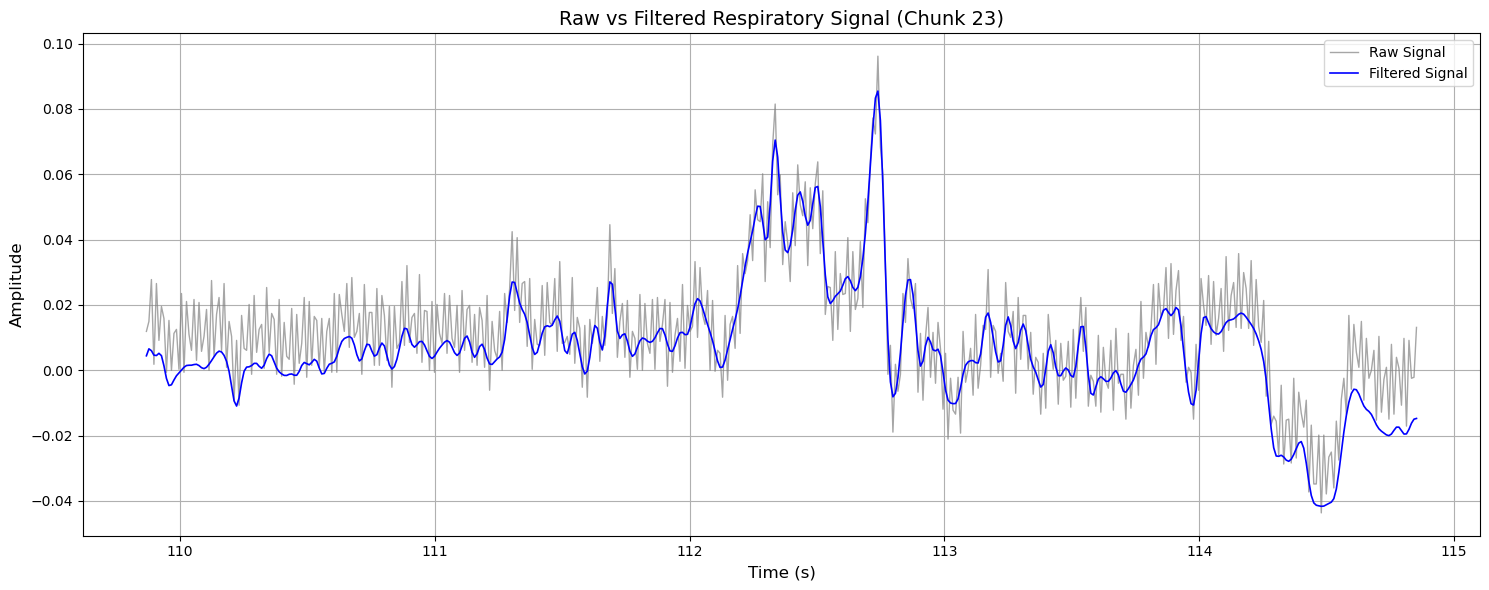

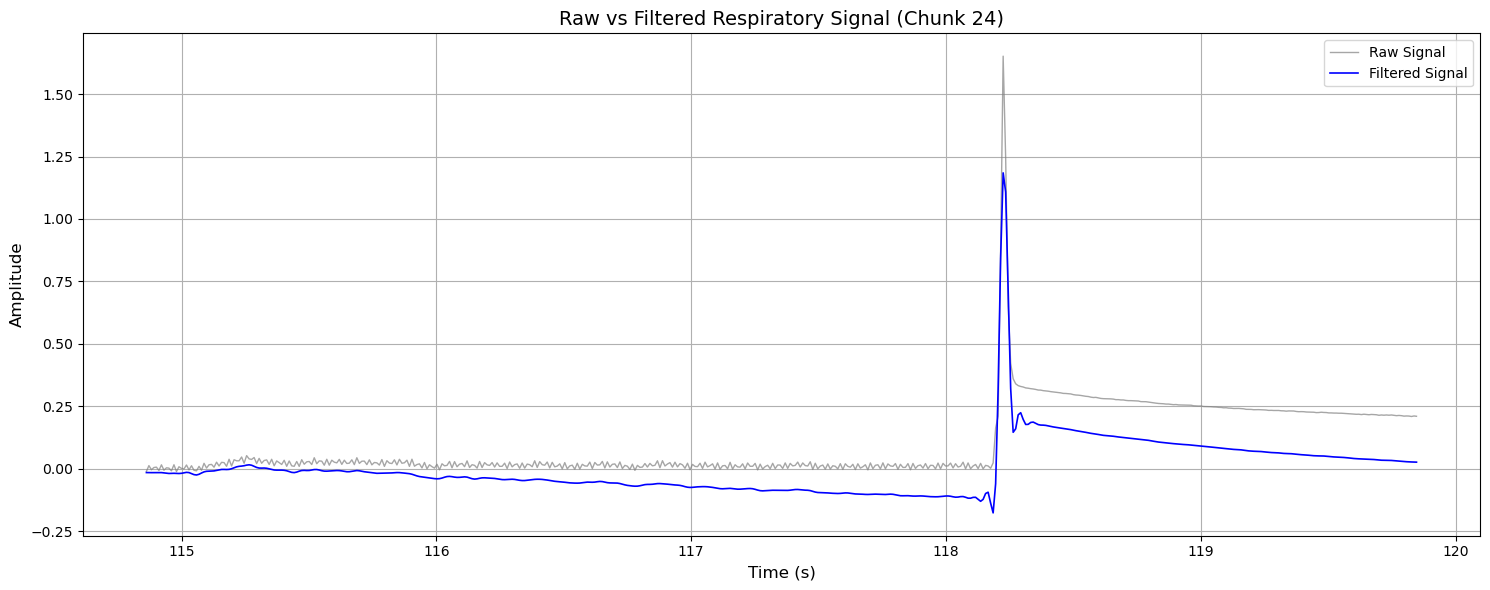

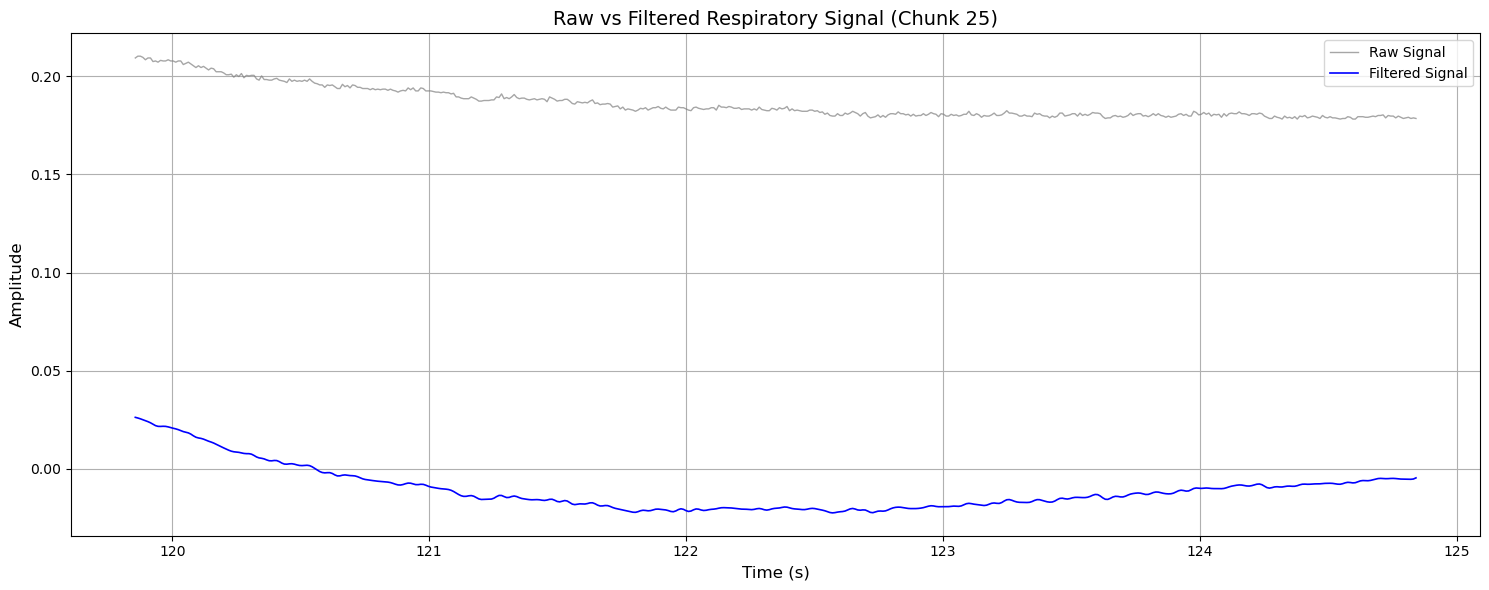

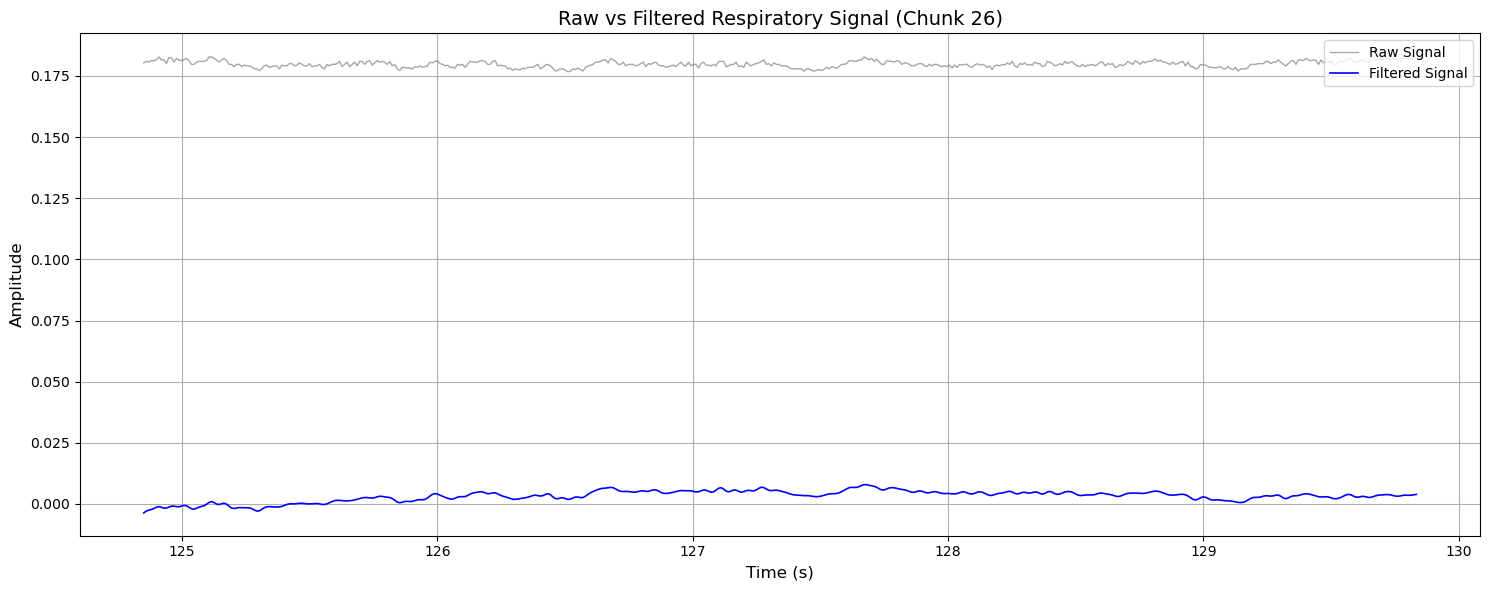

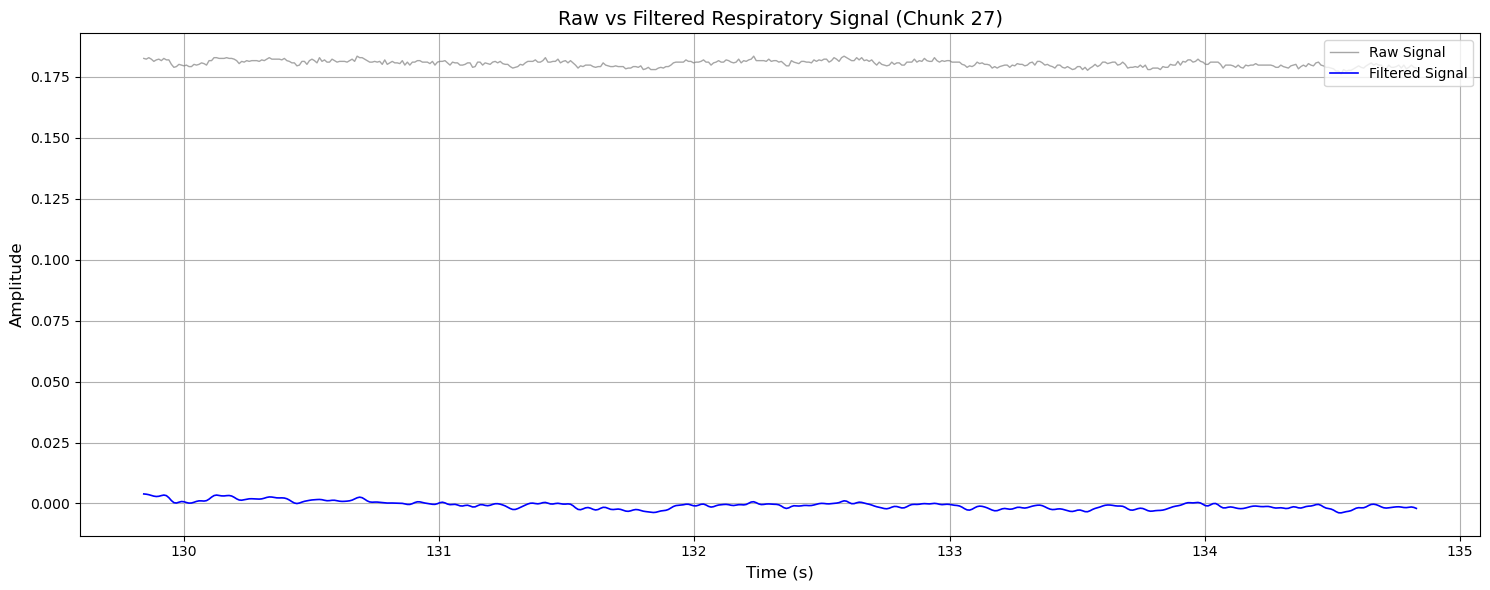

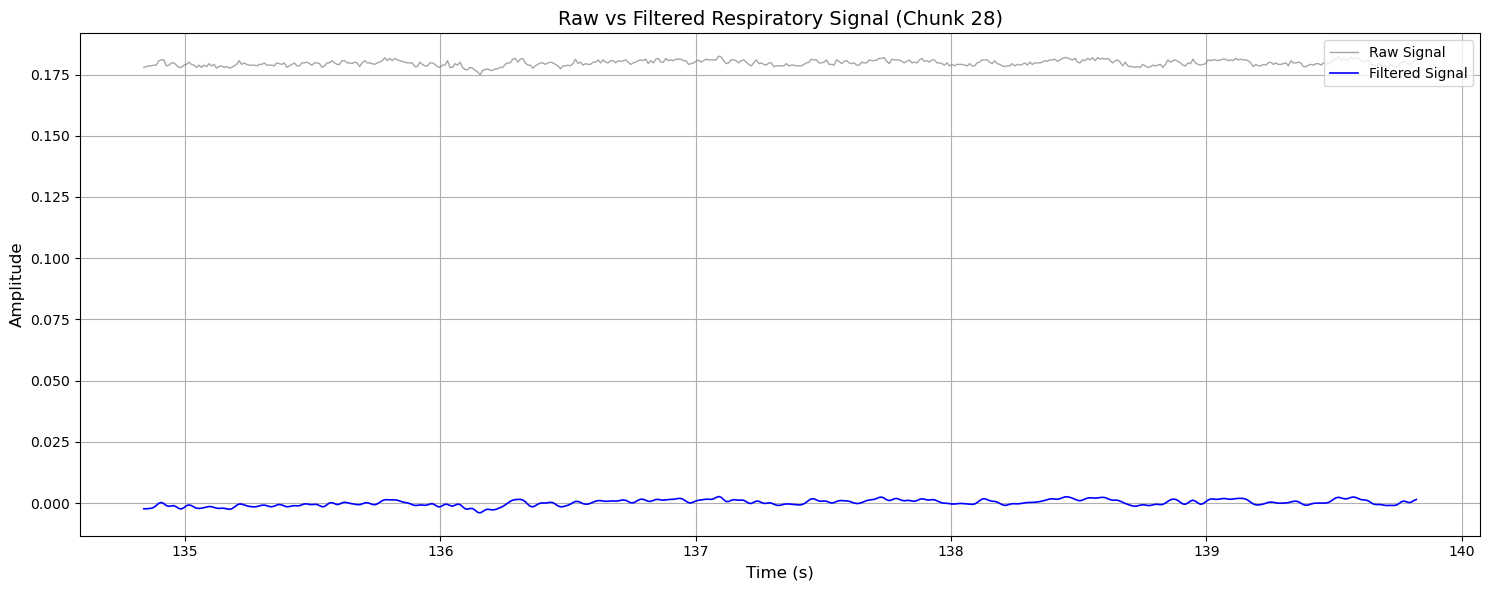

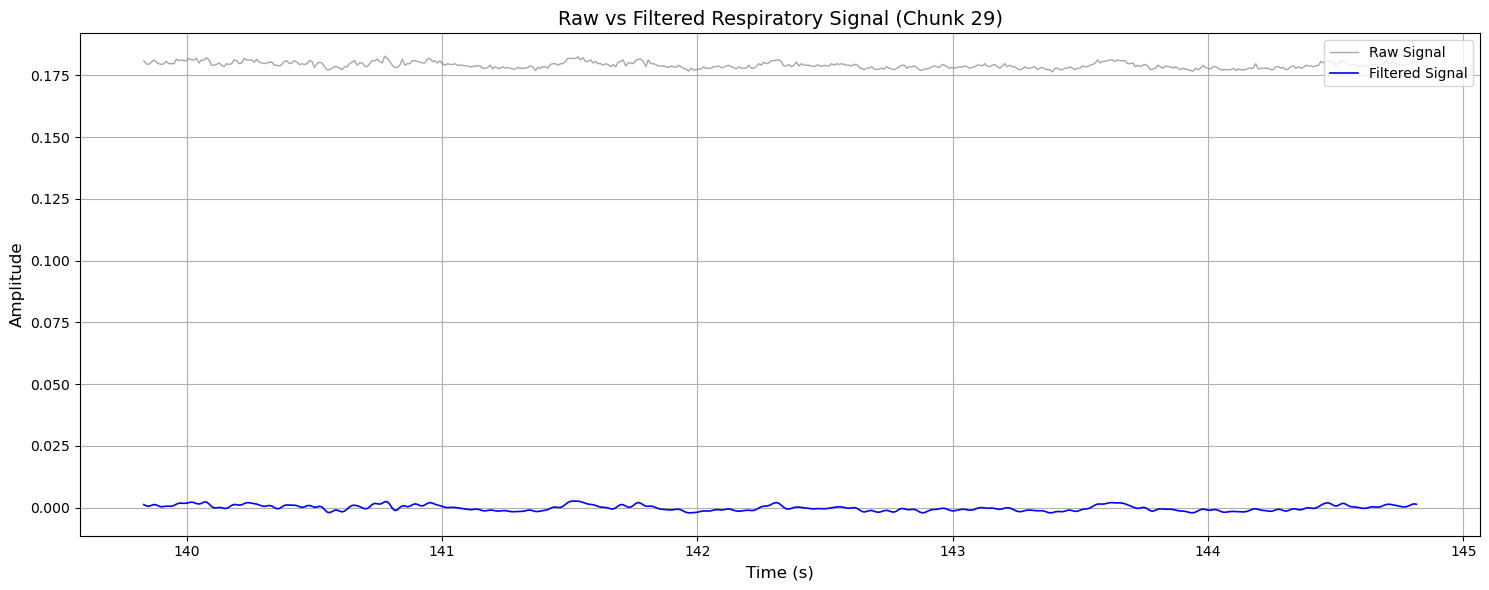

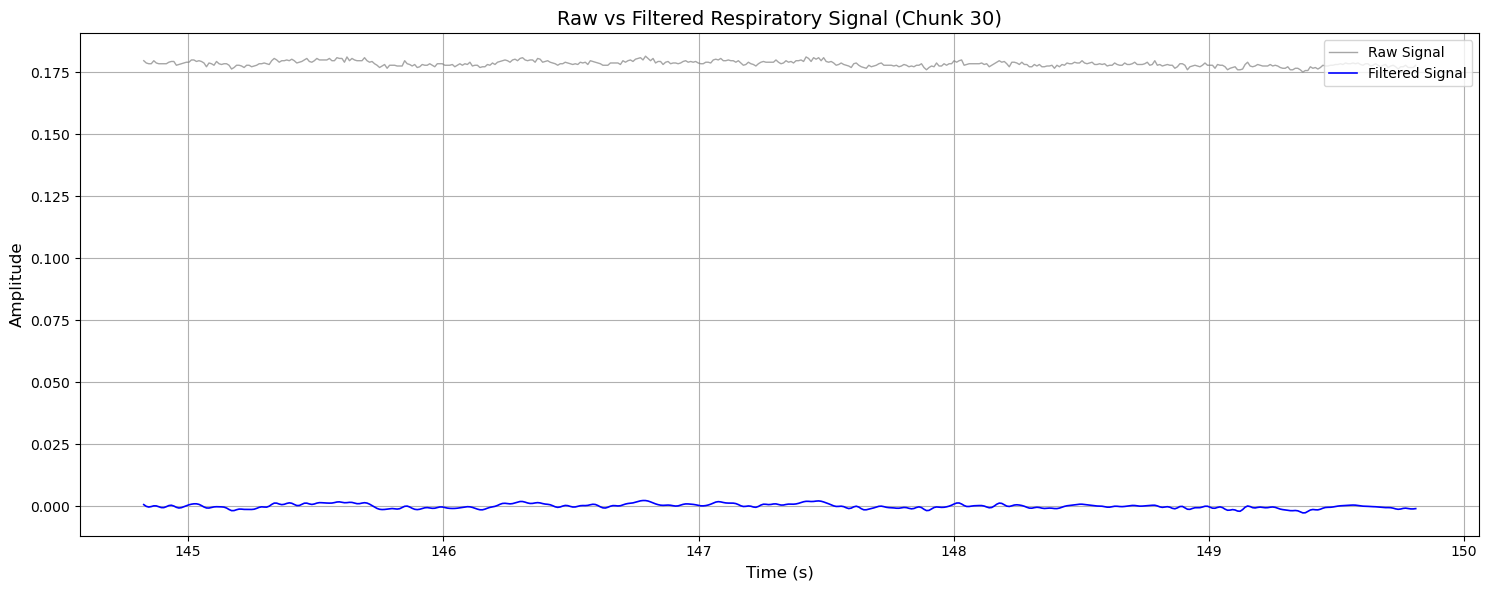

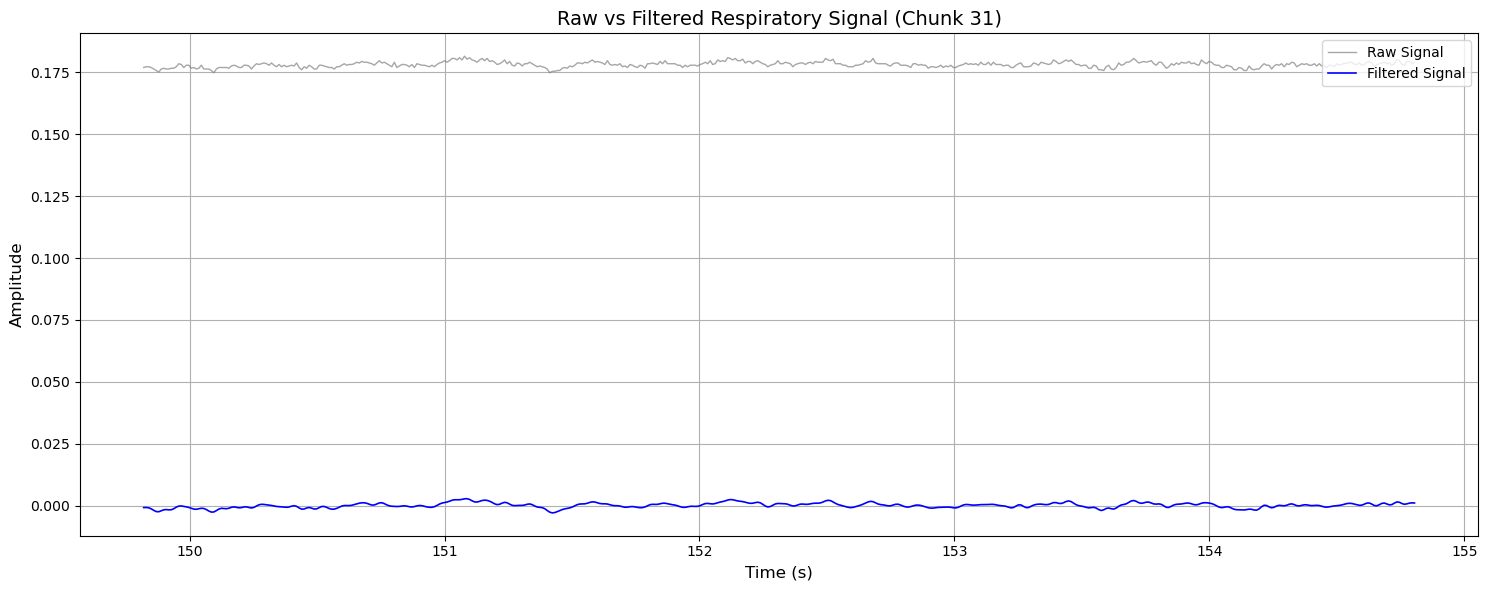

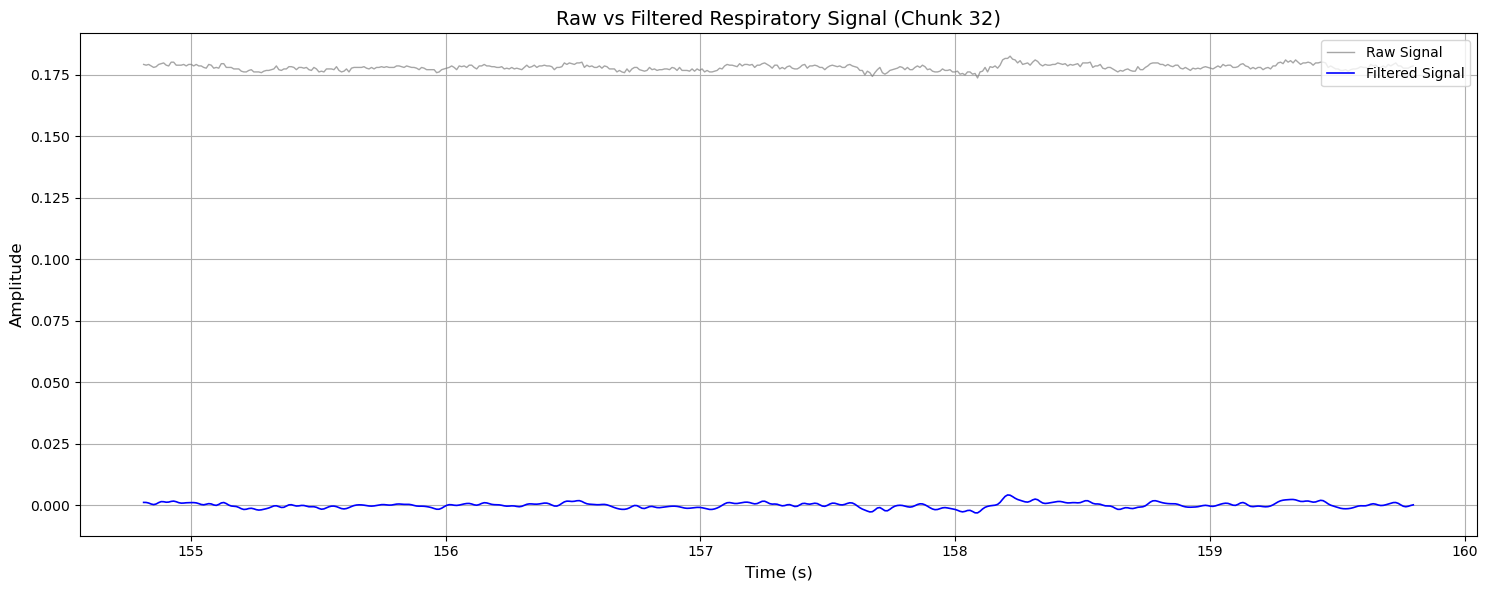

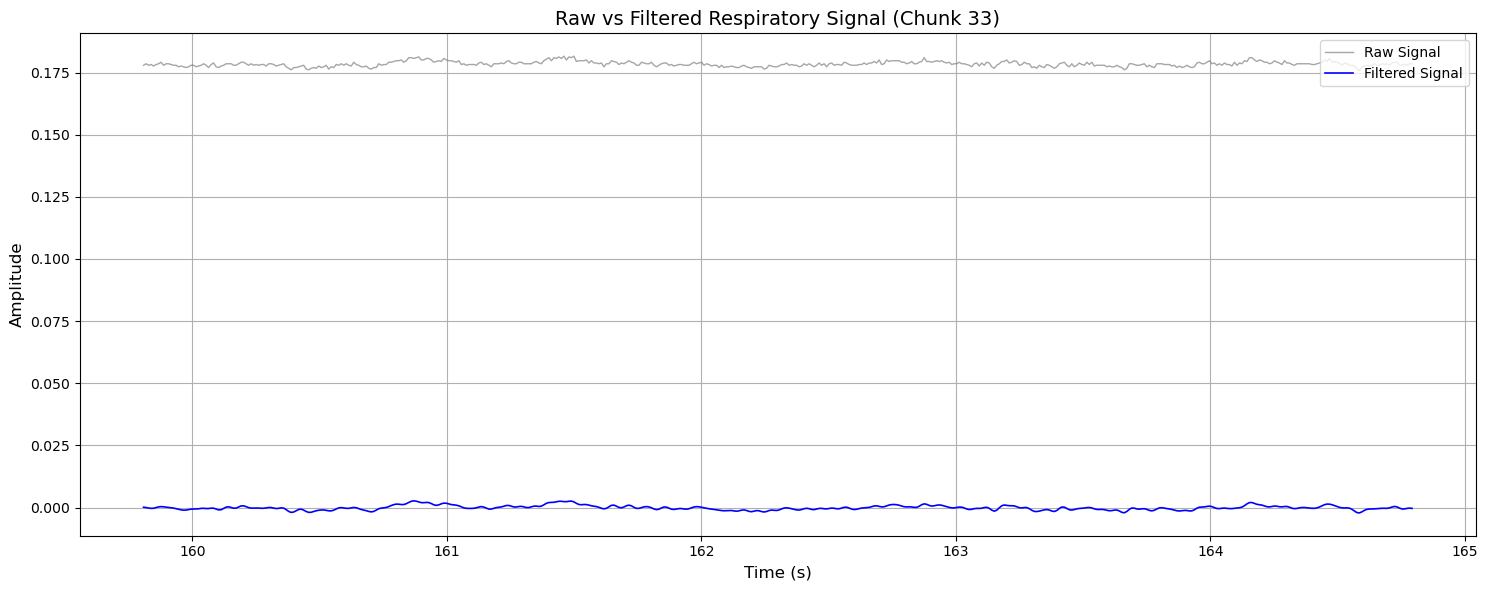

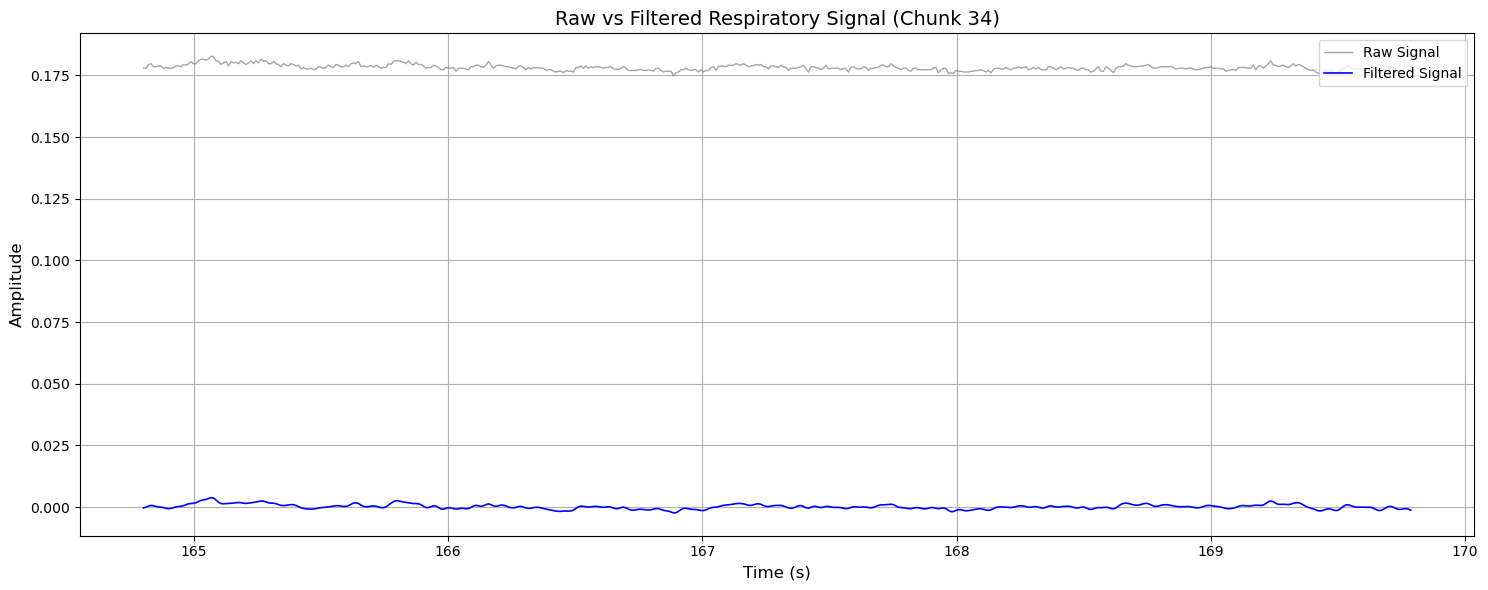

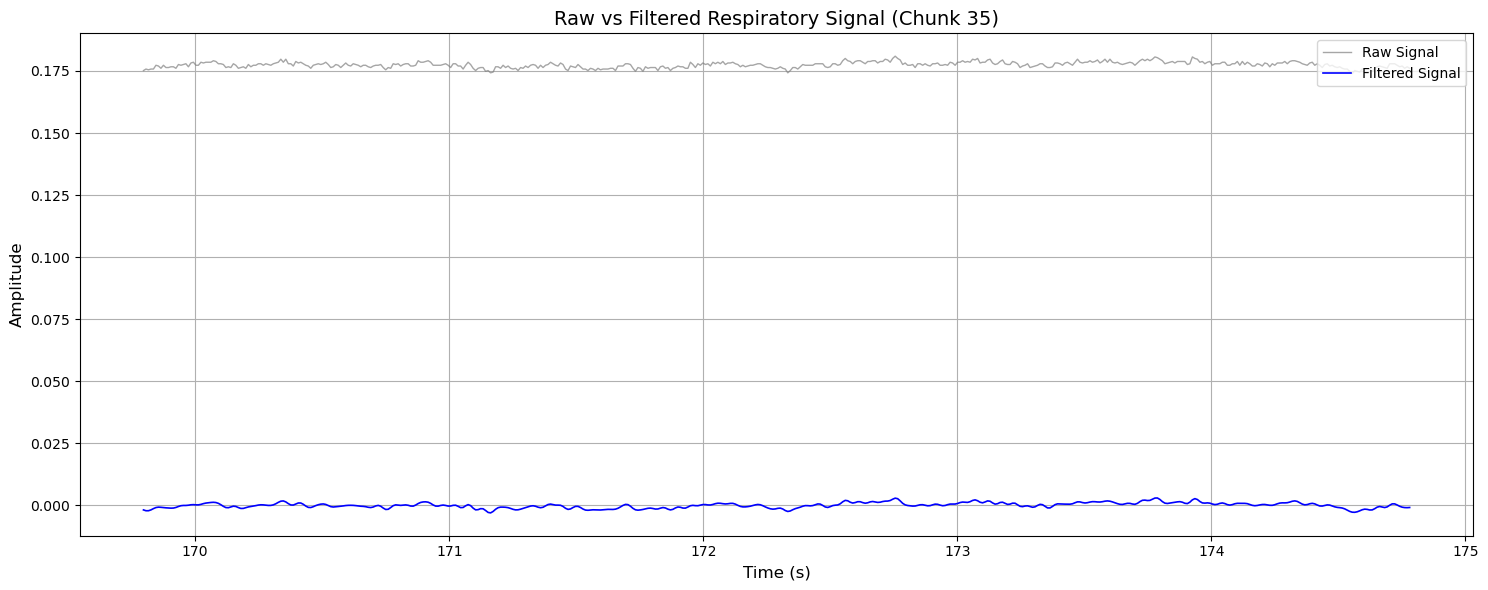

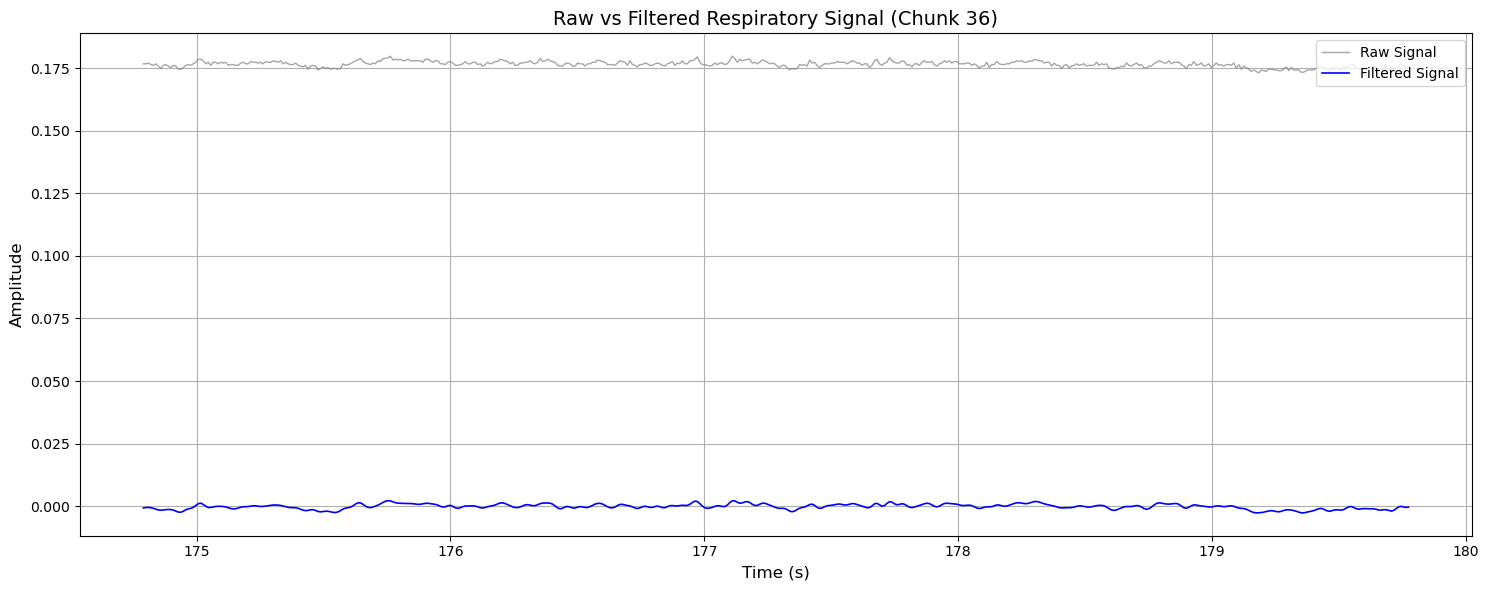

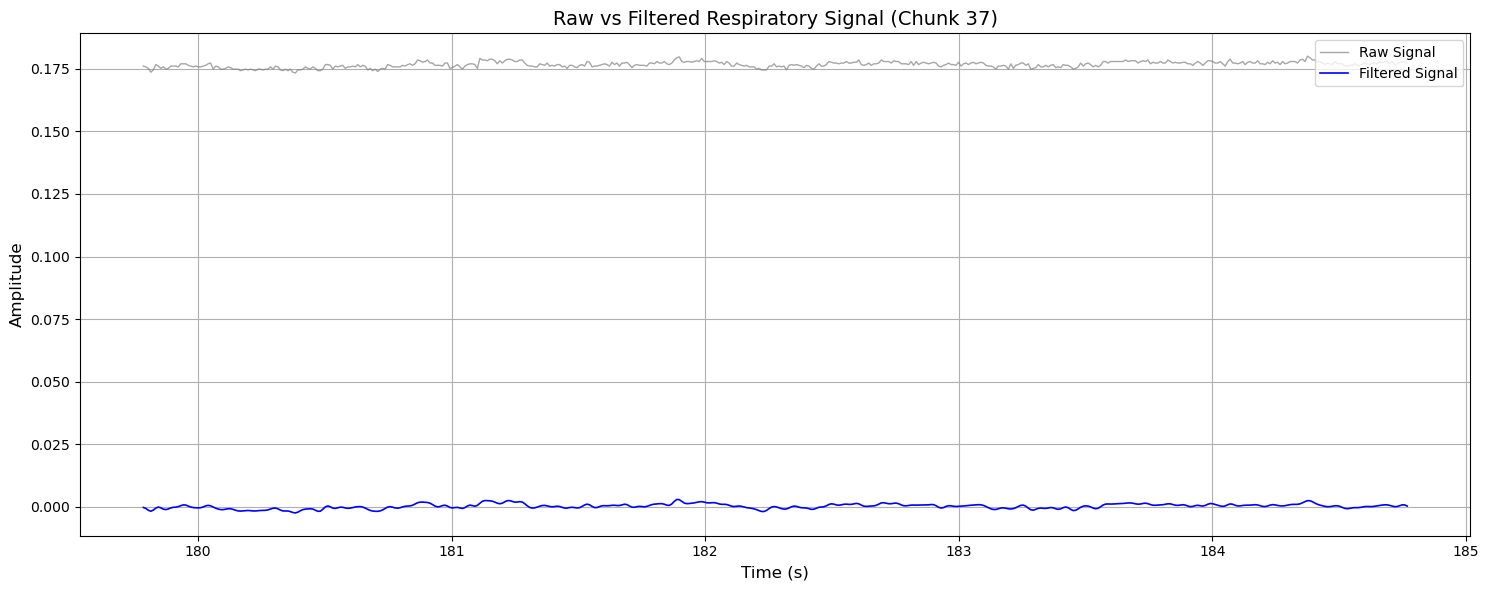

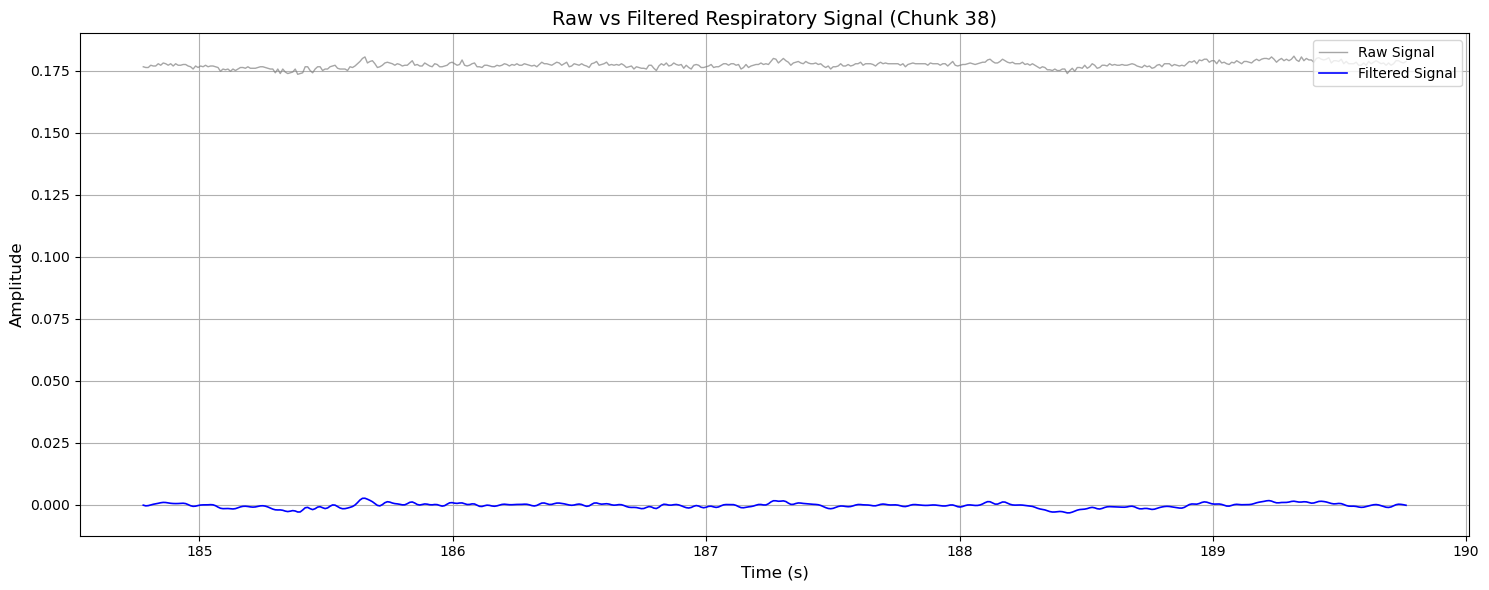

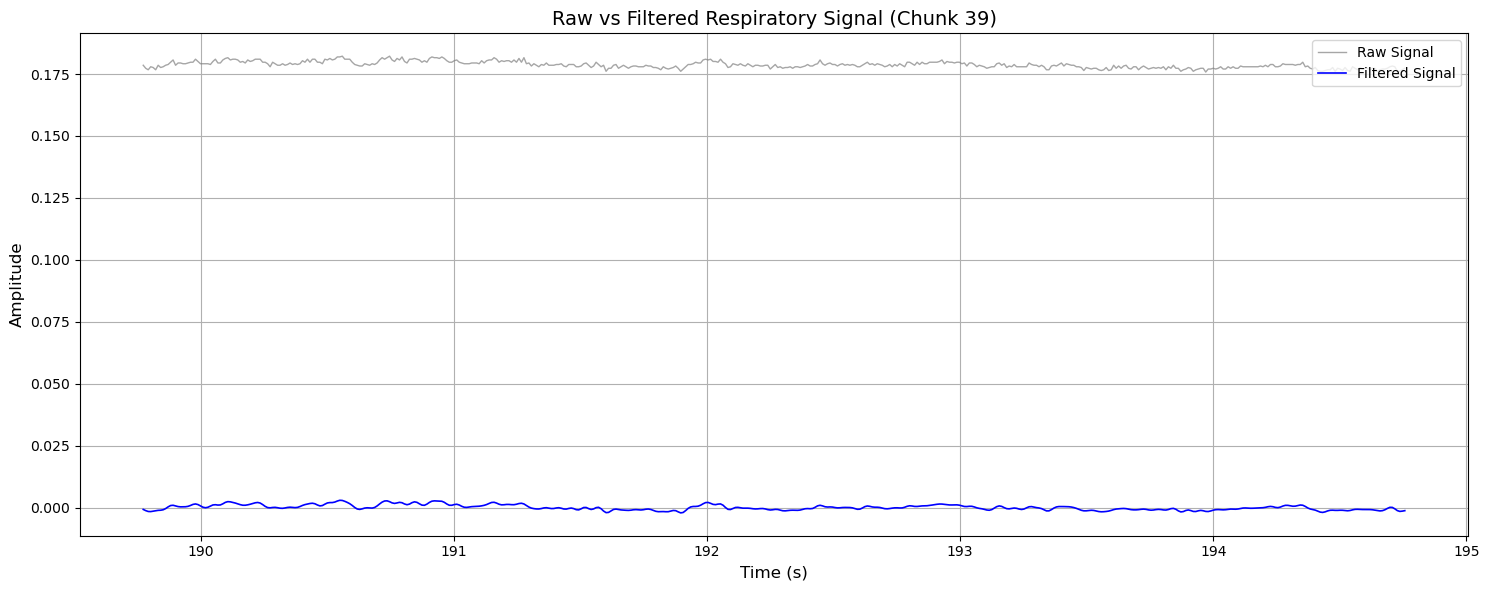

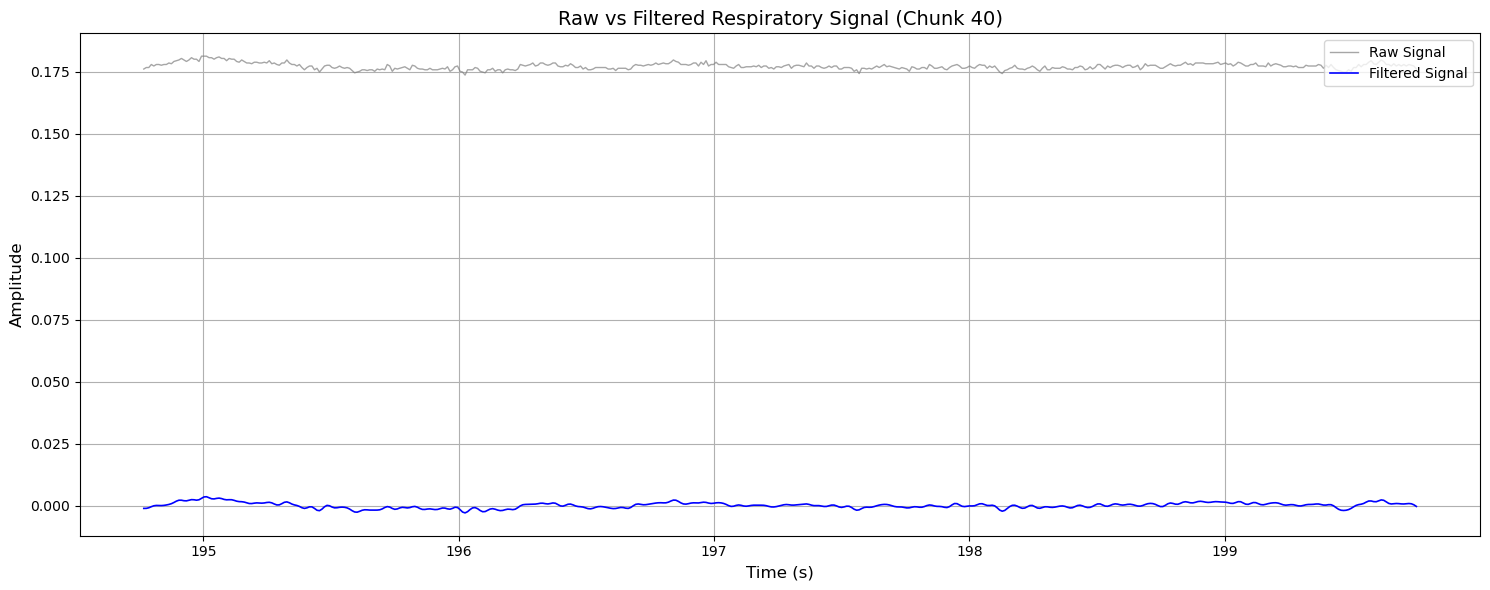

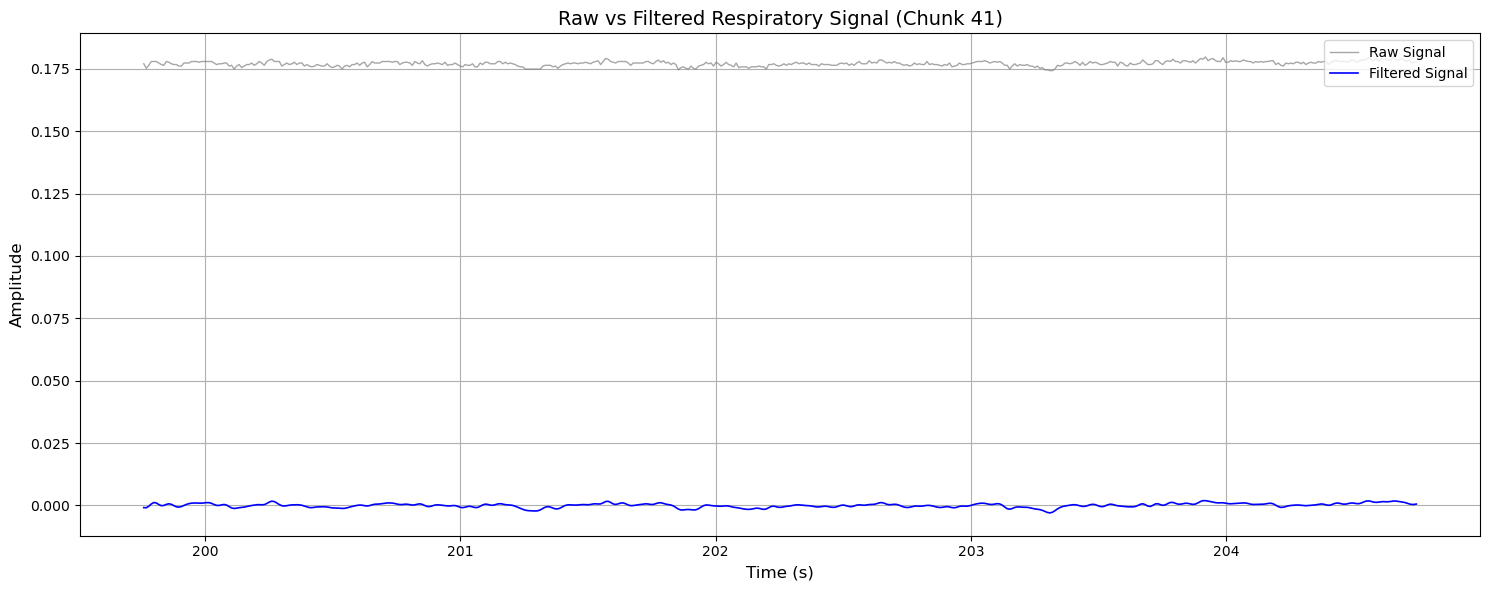

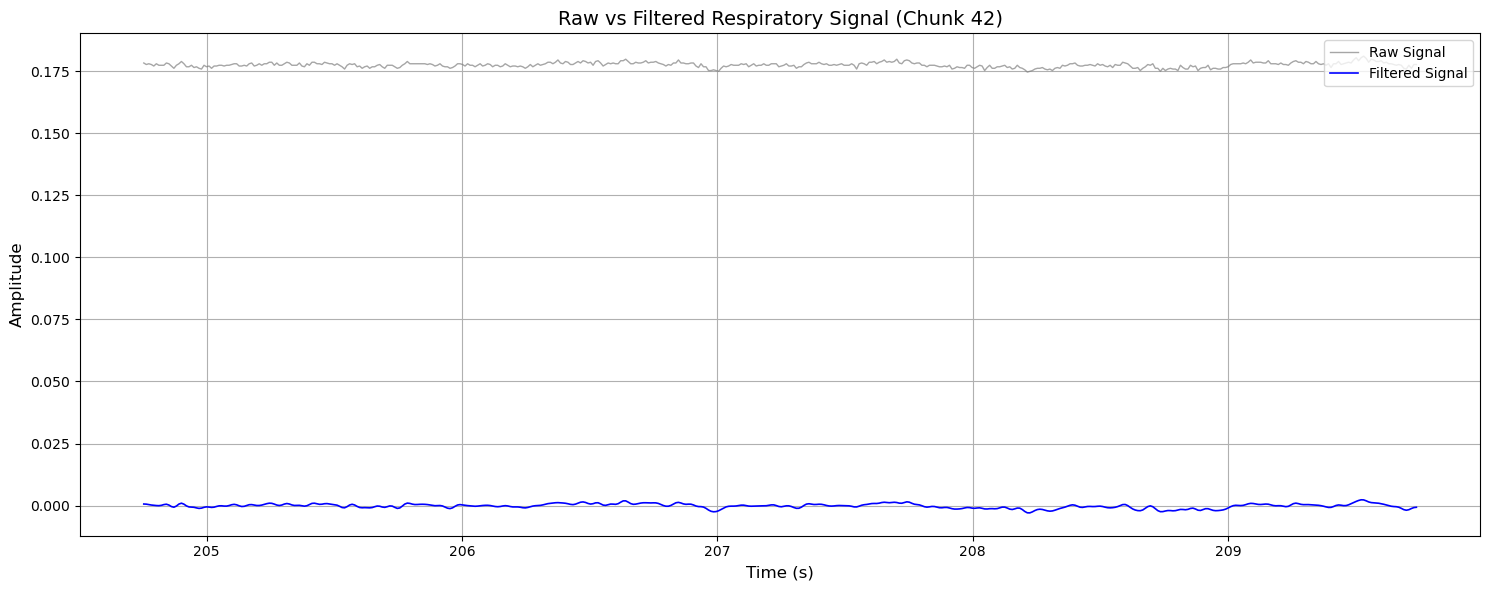

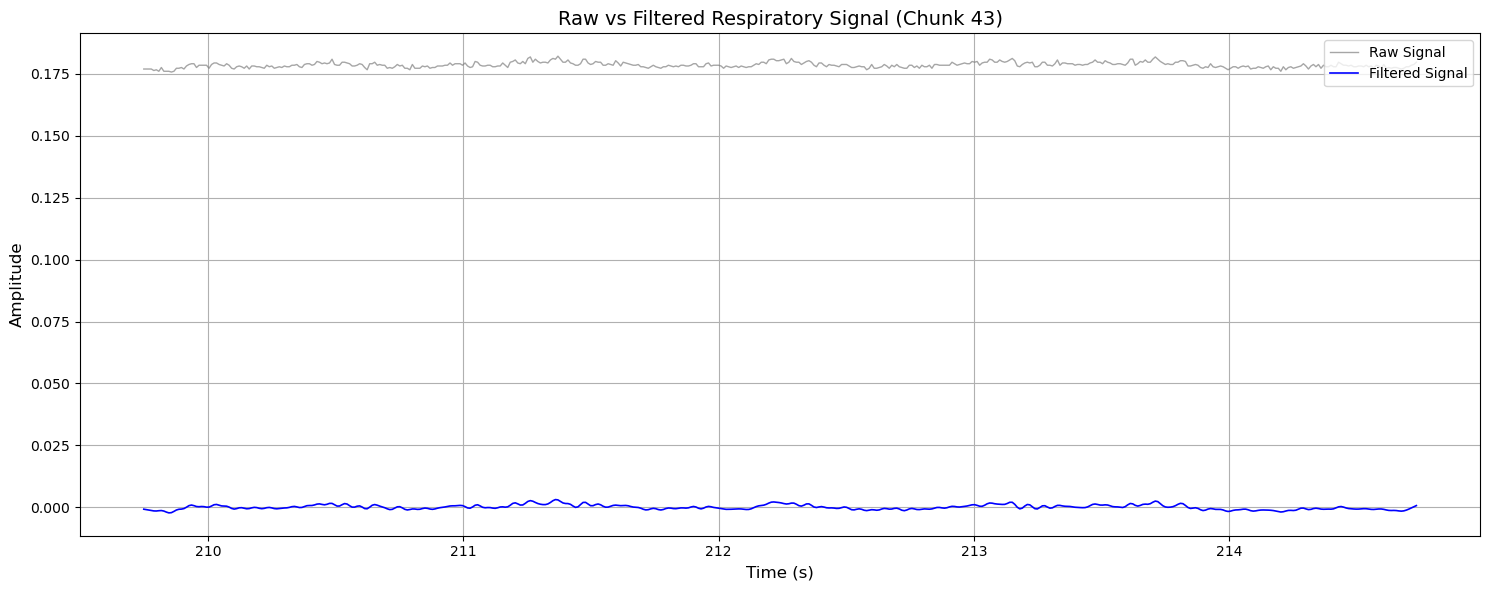

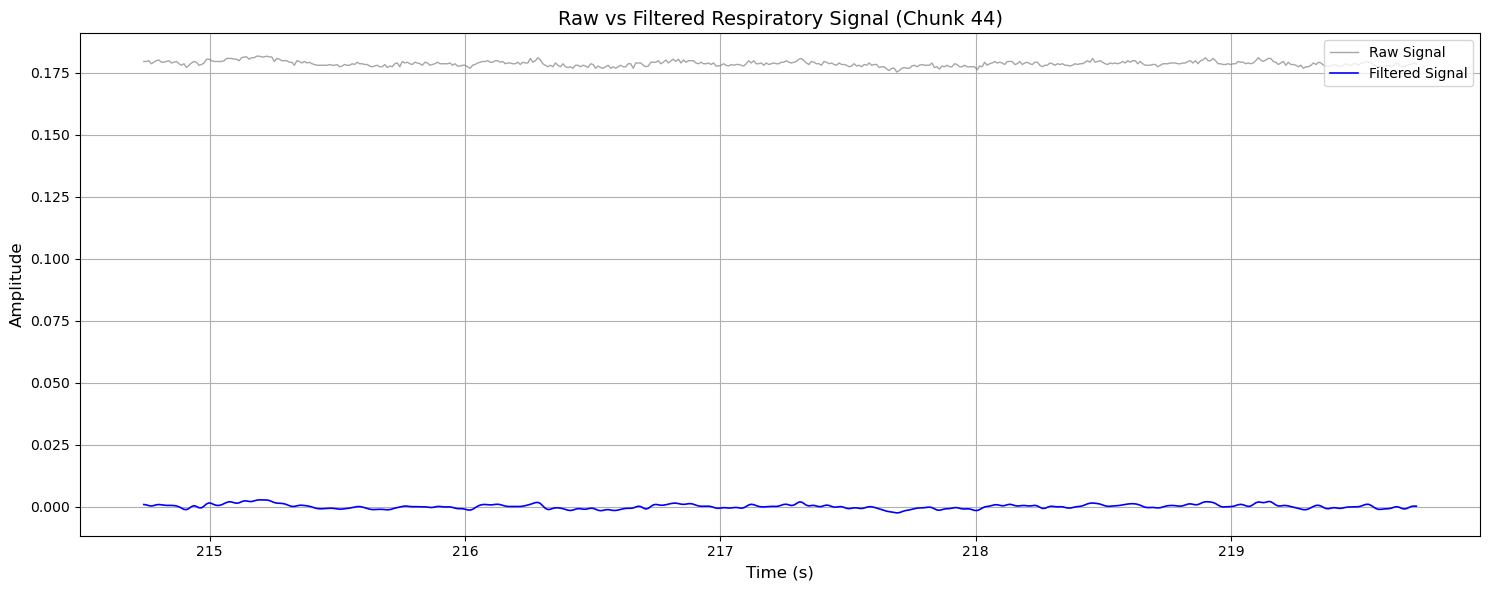

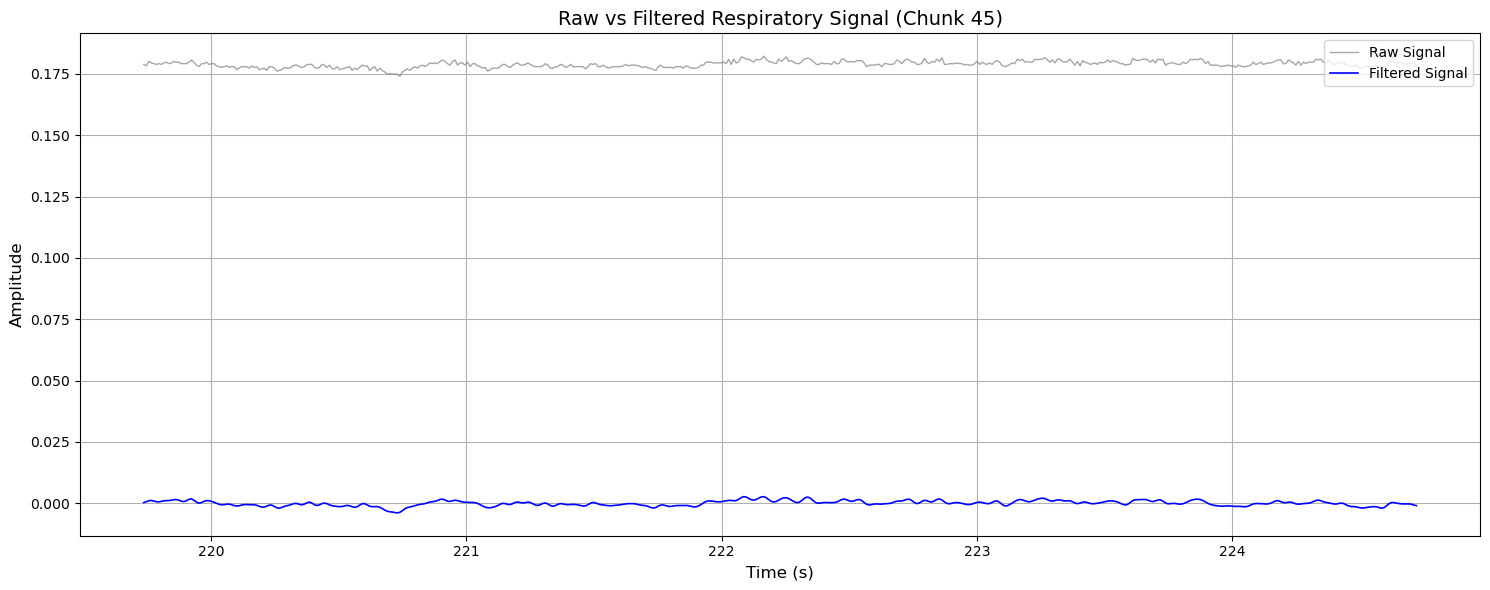

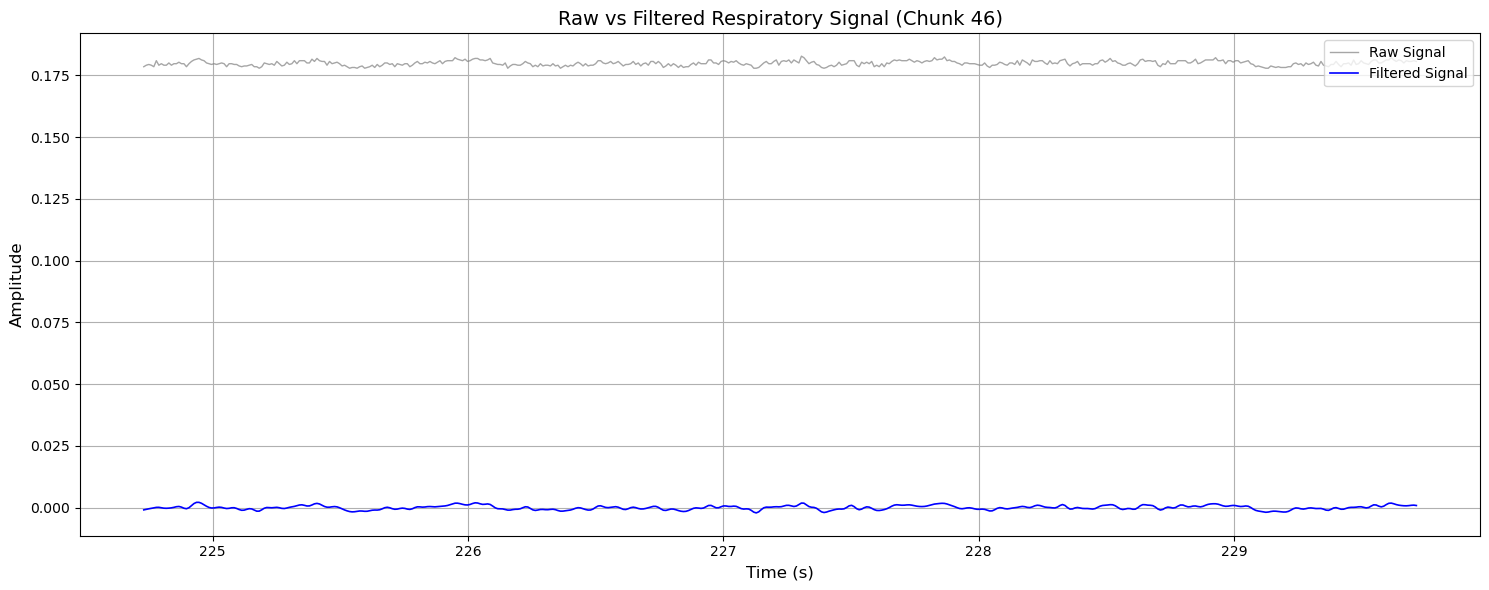

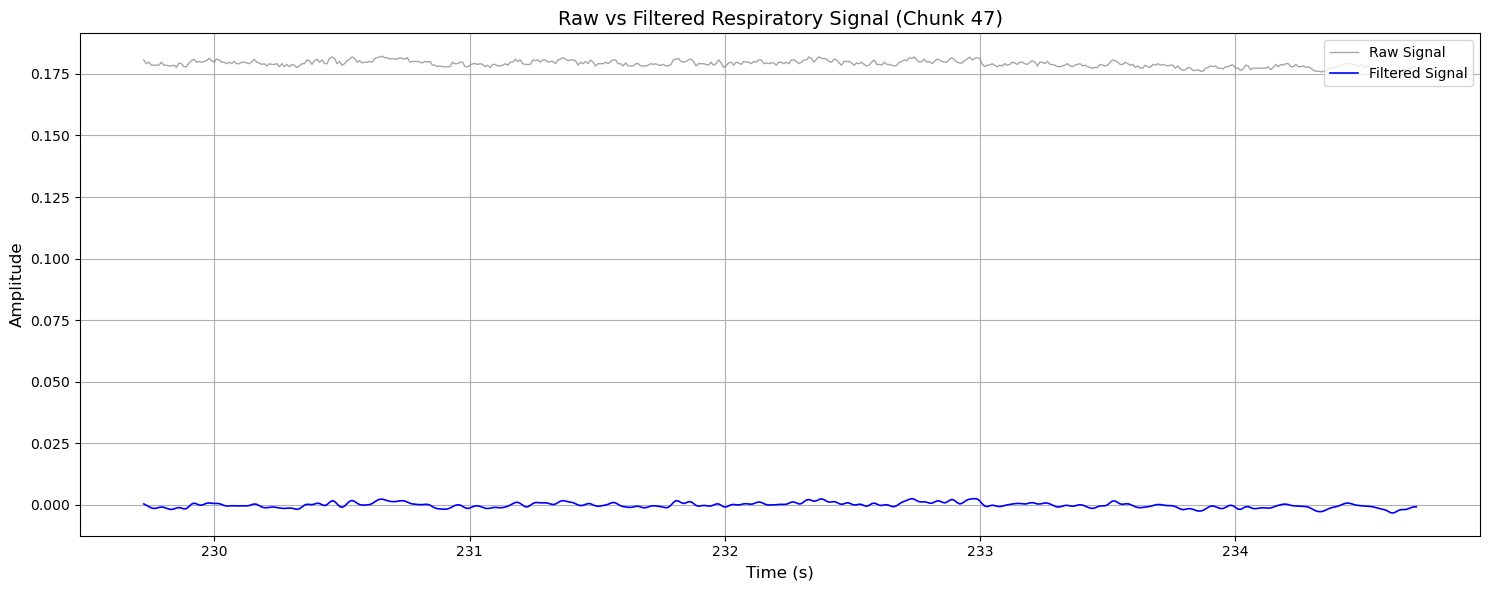

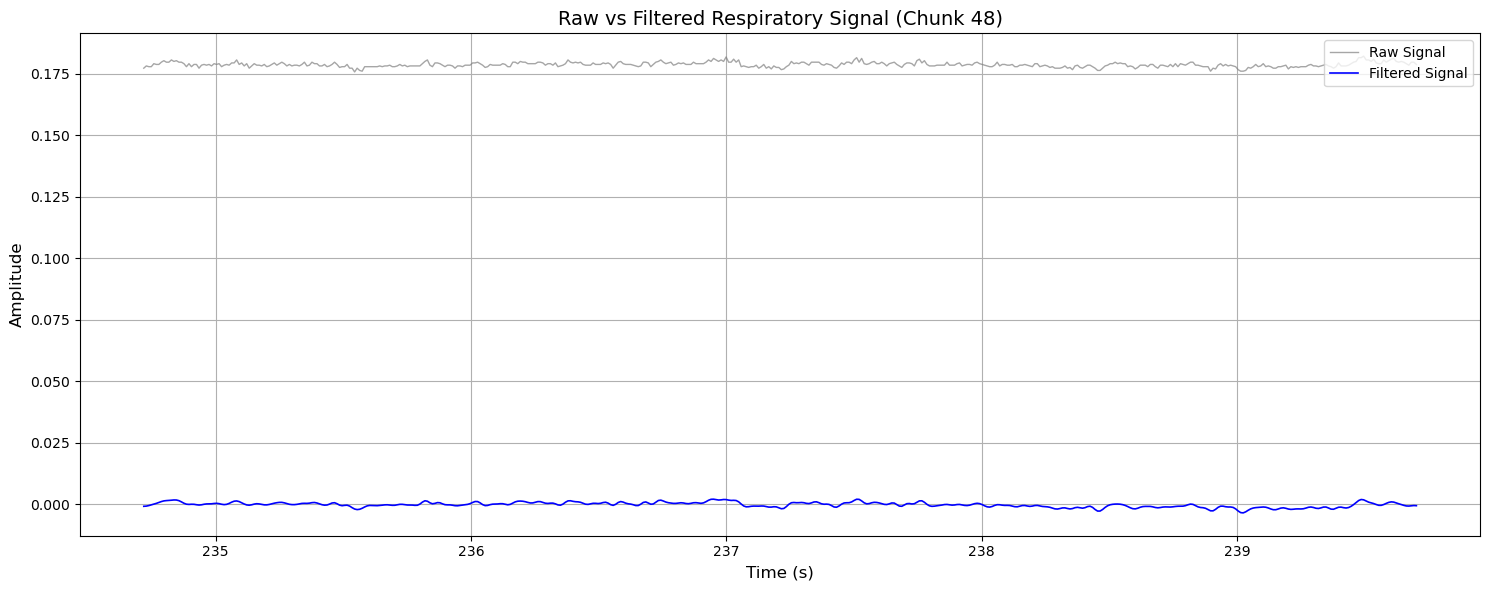

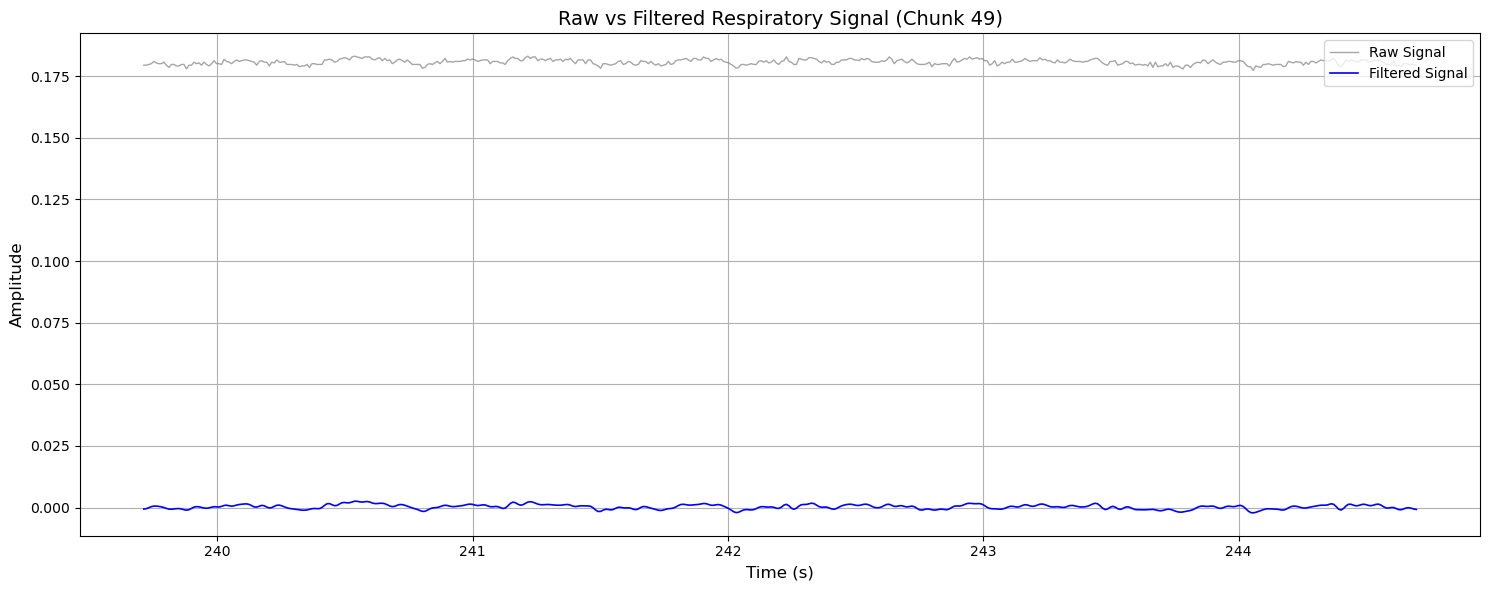

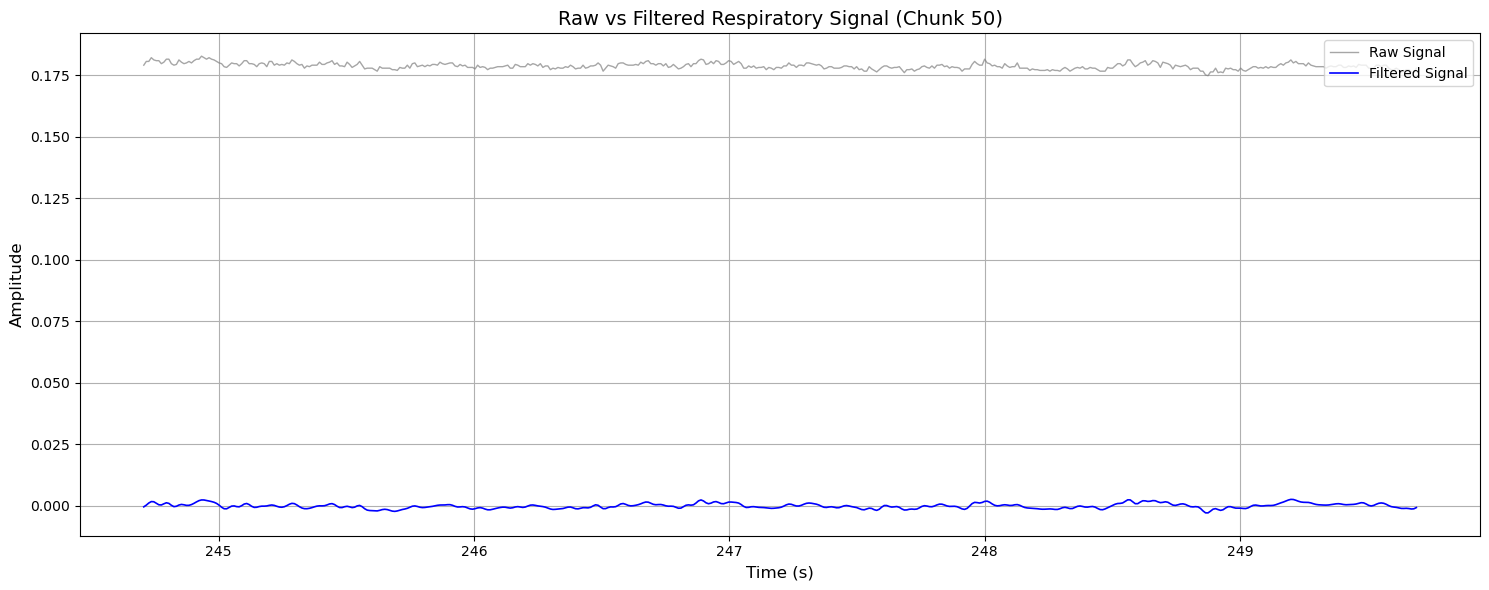

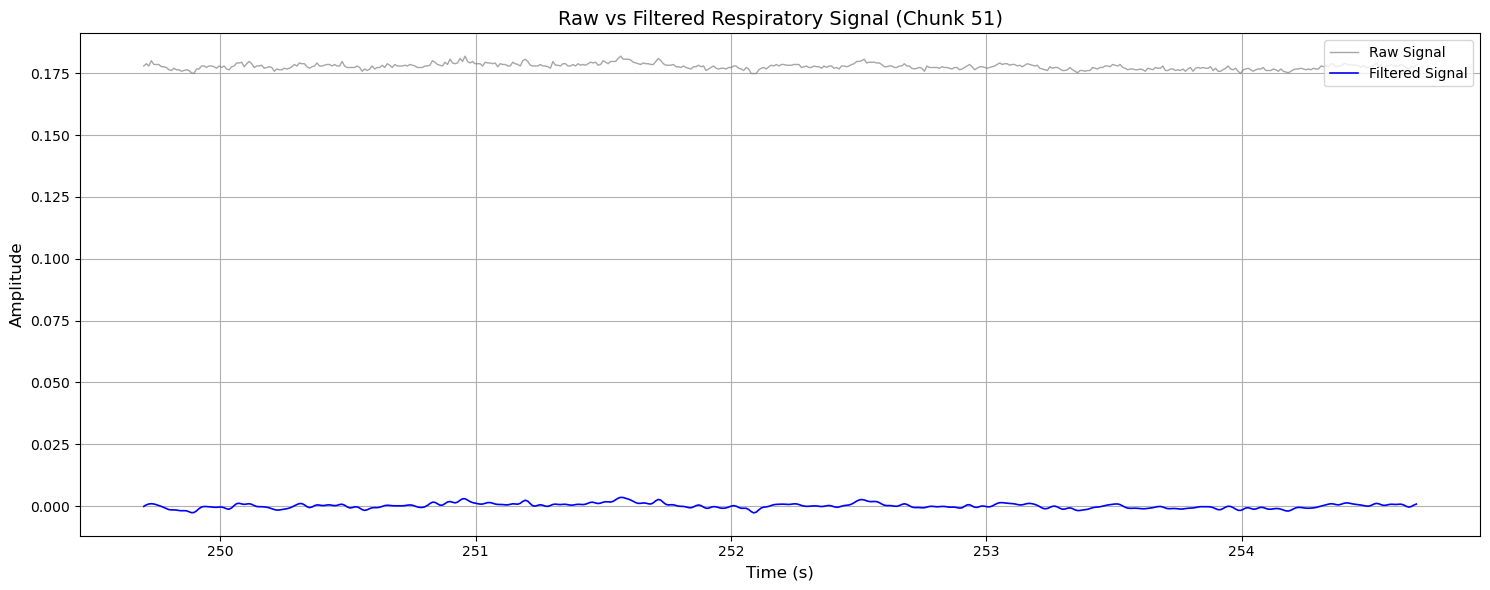

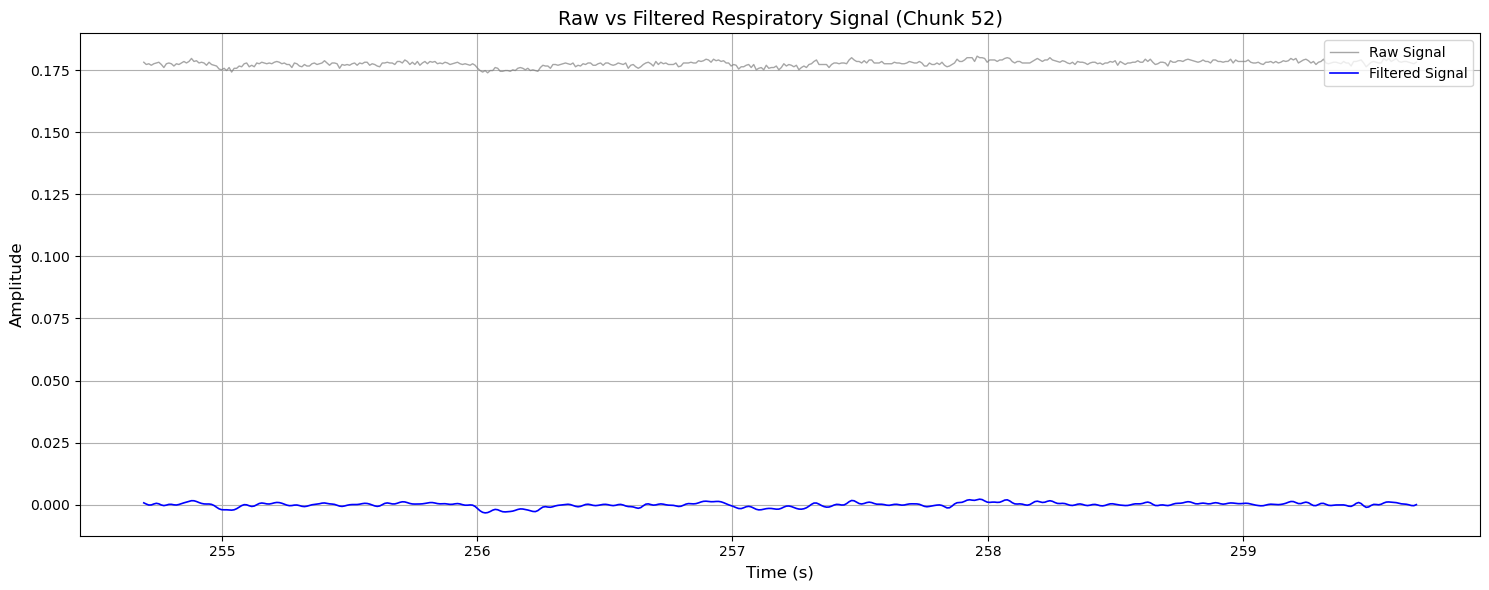

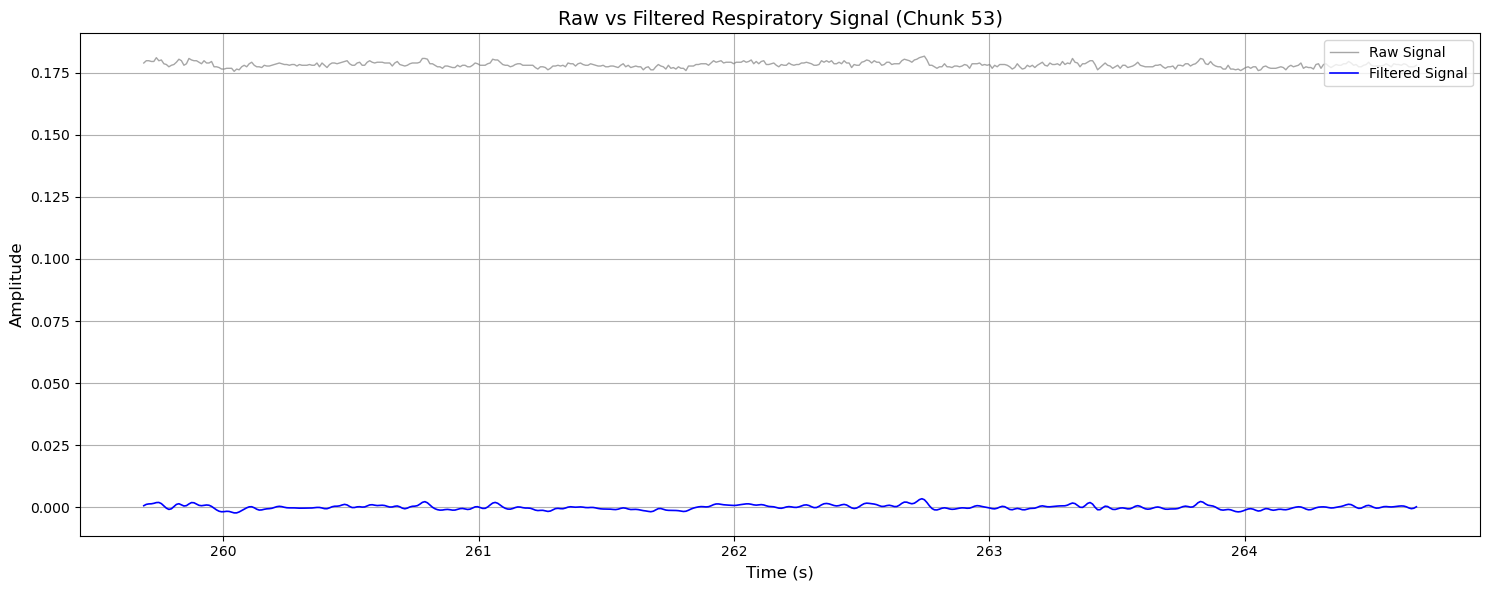

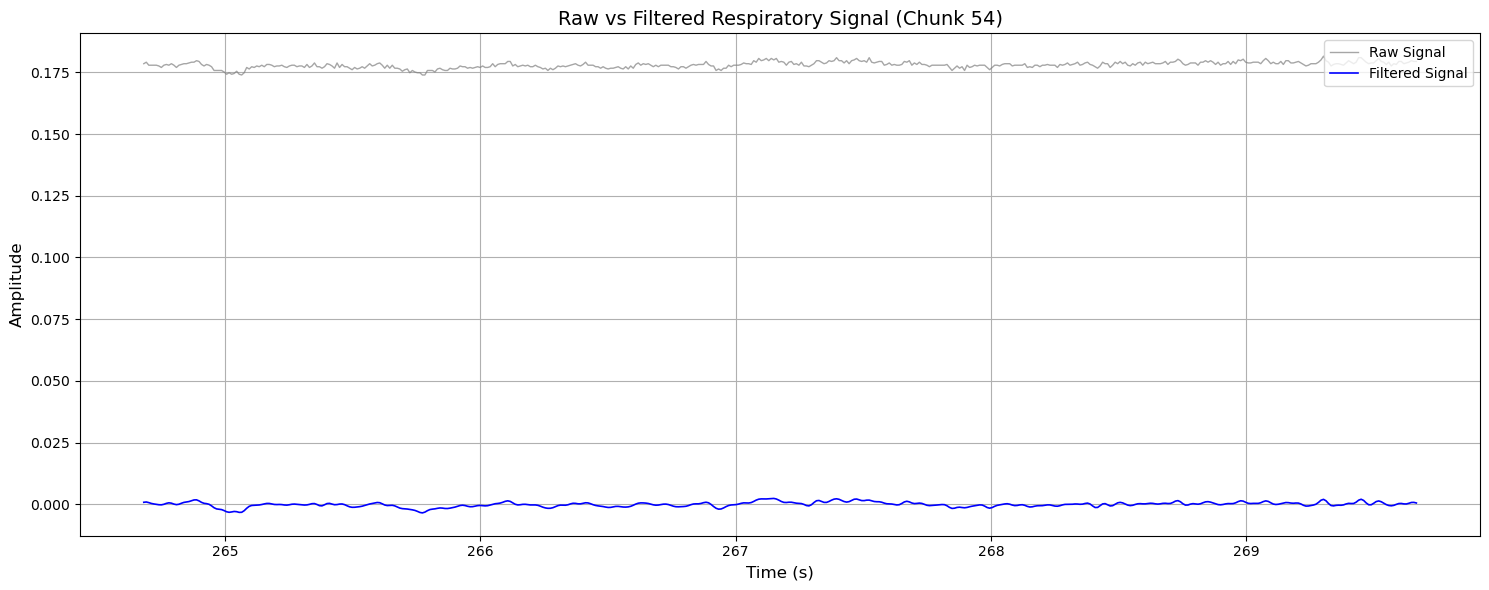

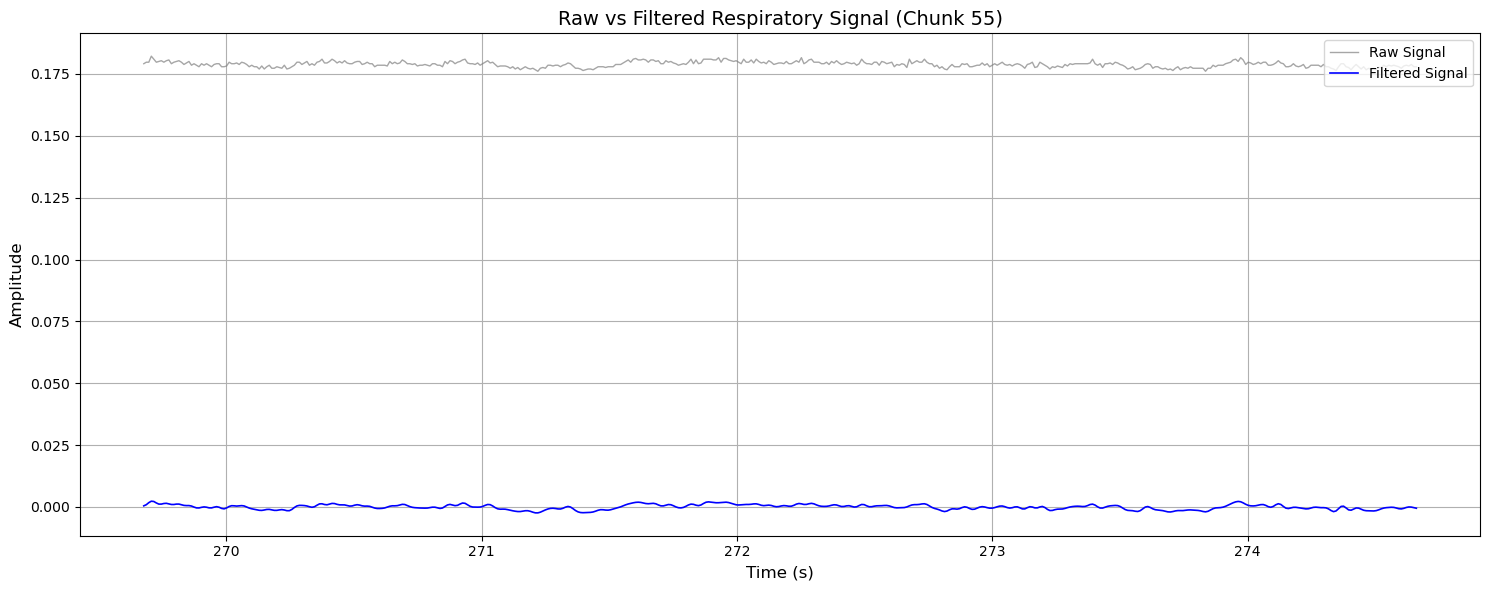

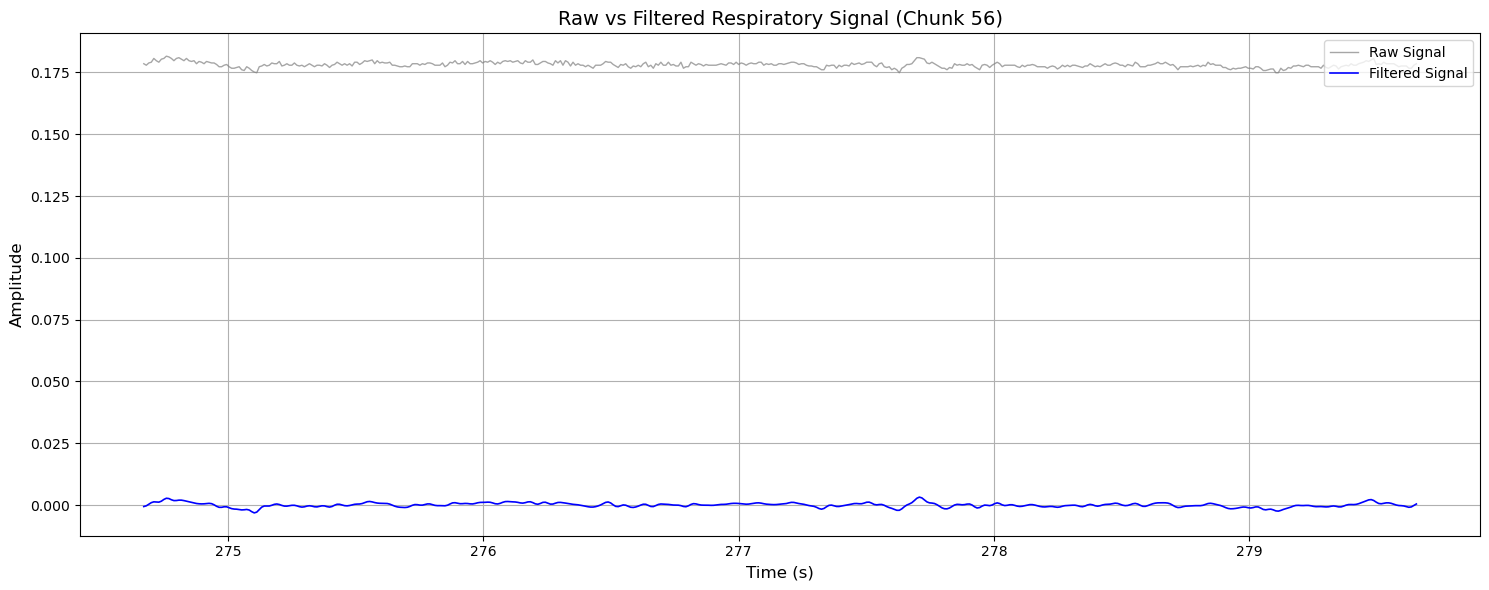

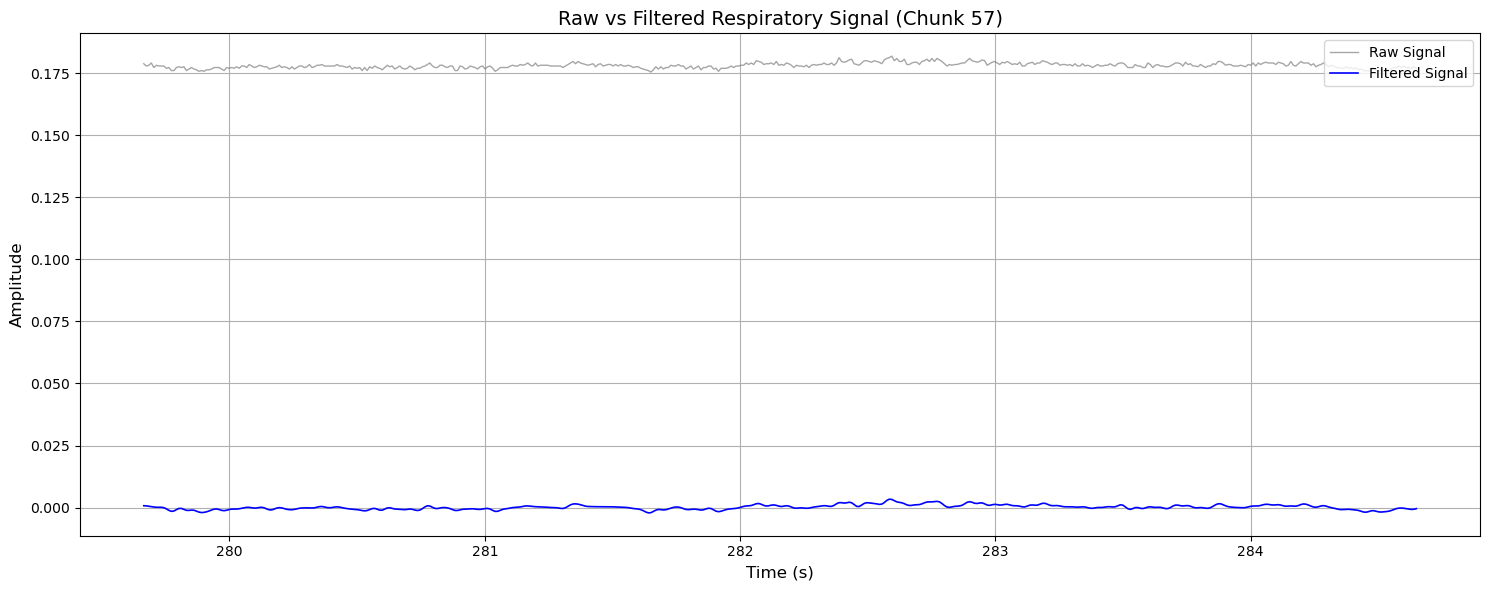

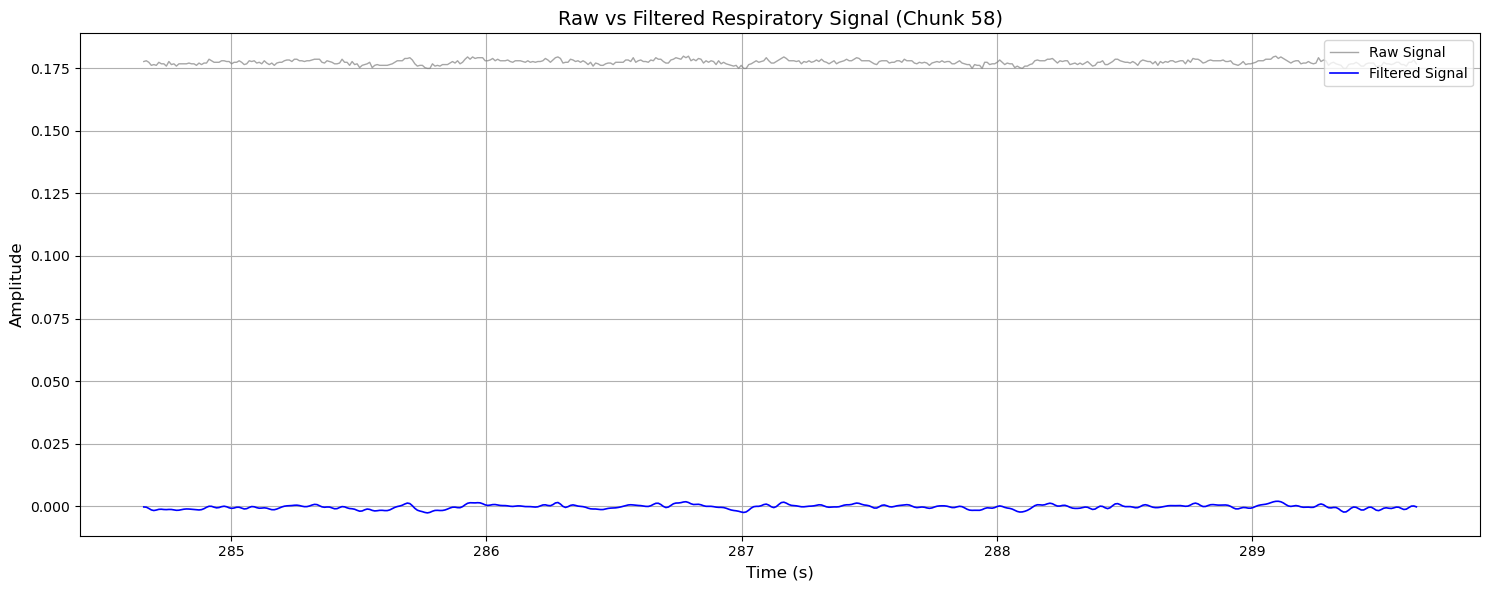

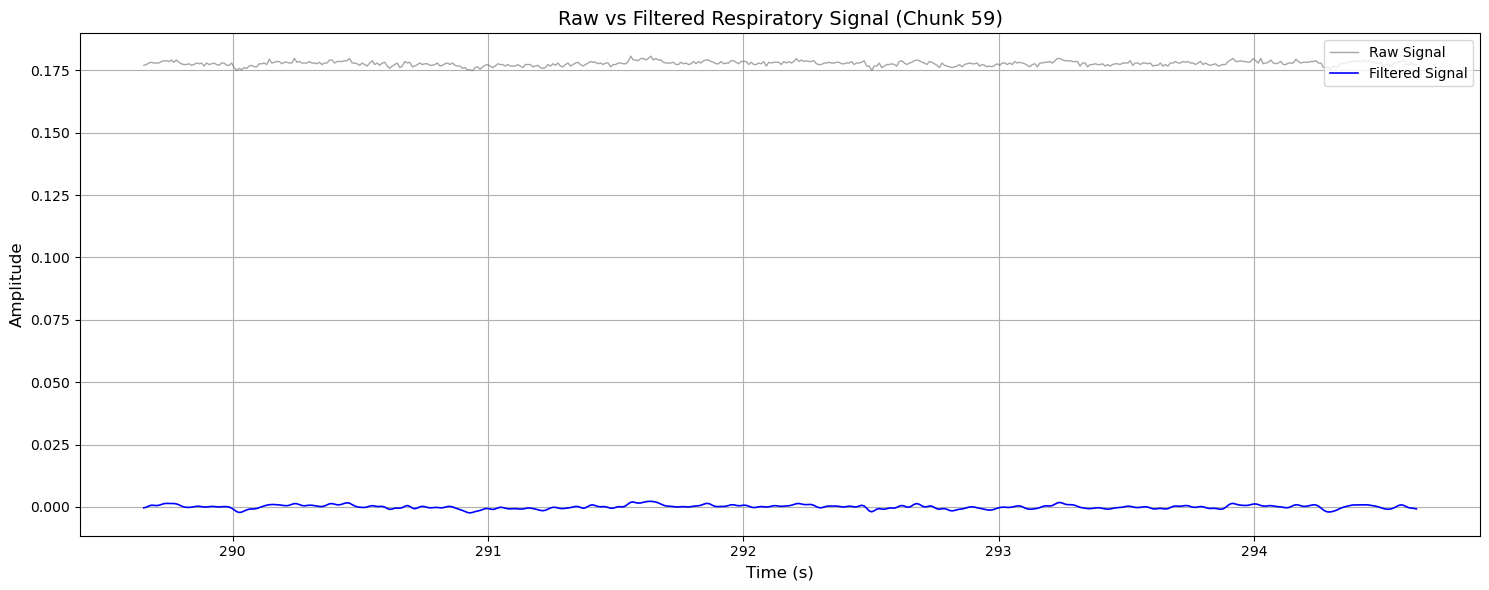

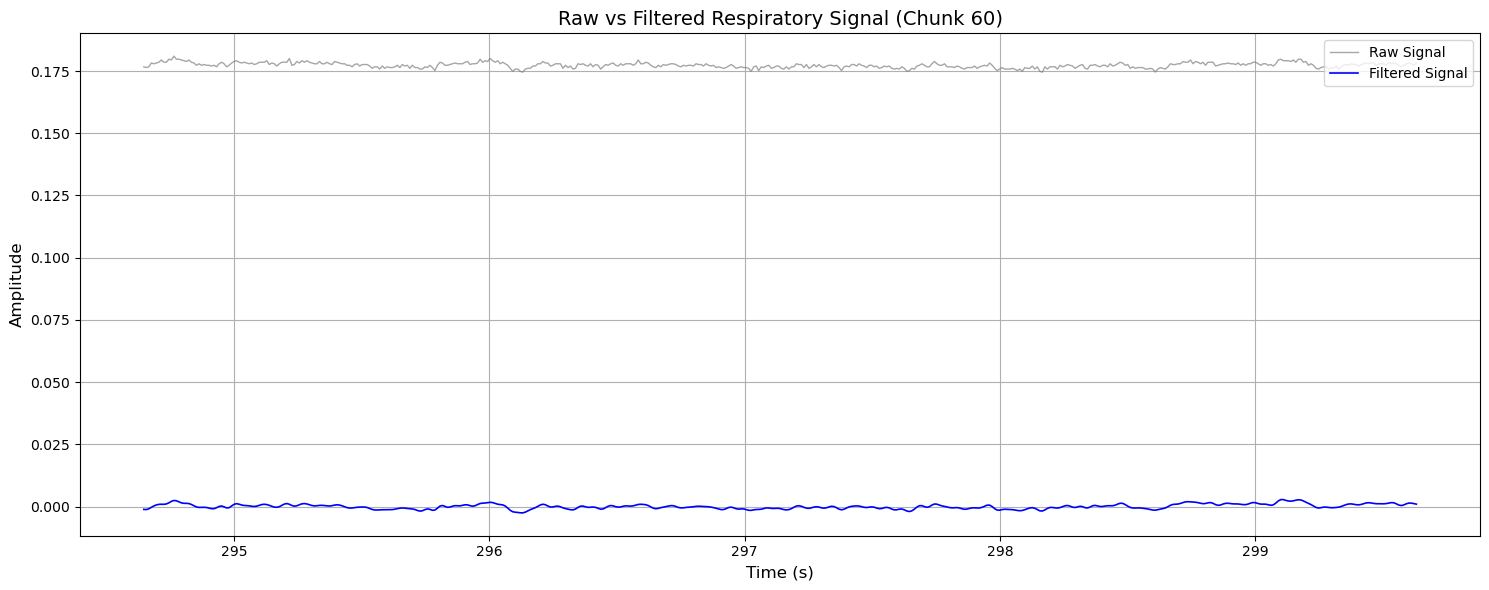

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import neurokit2 as nk
import tdt

# Load the TDT block
tdt_file_path = r"E:\resp_test_data\mouse5-250125-100112"
data = tdt.read_block(tdt_file_path)

# Extract respiratory signal
rsp_signal = data.streams['Resp'].data  # Adjust 'Resp' to match your stream name
srate = data.streams['Resp'].fs  # Sampling rate (Hz)
total_duration = len(rsp_signal) / srate  # Total duration in seconds
time_array = np.linspace(0, total_duration, len(rsp_signal))

# Smooth the respiratory signal
rsp_cleaned = nk.signal_filter(
    rsp_signal,
    lowcut=0.1,   # Low cutoff frequency (Hz)
    highcut=20,   # High cutoff frequency (Hz)
    method="butterworth",  # Filtering method
    sampling_rate=srate,   # Sampling rate of the signal
    order=4                # Filter order
)

# Chunk size (10 seconds)
chunk_size = int(5 * srate)  # Number of samples per 10-second chunk
num_chunks = len(rsp_signal) // chunk_size  # Total number of full chunks

# Plot each chunk
for i in range(num_chunks):
    start_idx = i * chunk_size
    end_idx = start_idx + chunk_size

    # Get the time and signal for the current chunk
    chunk_time = time_array[start_idx:end_idx]
    chunk_raw = rsp_signal[start_idx:end_idx]
    chunk_filtered = rsp_cleaned[start_idx:end_idx]

    # Plot the current chunk
    plt.figure(figsize=(15, 6))
    plt.plot(chunk_time, chunk_raw, label="Raw Signal", color="gray", alpha=0.7, linewidth=1)
    plt.plot(chunk_time, chunk_filtered, label="Filtered Signal", color="blue", linewidth=1.2)
    plt.xlabel("Time (s)", fontsize=12)
    plt.ylabel("Amplitude", fontsize=12)
    plt.title(f"Raw vs Filtered Respiratory Signal (Chunk {i+1})", fontsize=14)
    plt.legend(loc="upper right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
